# SC foundation model 기초: 임베딩, 통합, Fien-tuning과 Perturbation 까지

딥러닝 모델인 Geneformer로 PBMC 세포를 임베딩해 annotation·batch 통합·perturbation으로 해석하고, zero-shot과 fine-tuning이 무엇을 바꾸는지, 그리고 그 결과를 어디까지 주장할 수 있는지 점검합니다.

## 강의 목표

 - QC·normalization·HVG가 모델 입력(tokenization)과 어떻게 연결되는지.
 - Geneformer의 rank-value와 scGPT의 gene+expression이 무엇을 다르게 보존하는지.
 - 실제 Geneformer로 PBMC 임베딩을 뽑아 임베딩에 담긴 정보를 확인.
 - 독립 데이터로 fine-tuning하면 무엇이 바뀌나 확인.
 - in-silico perturbation (effect_shift) 확인.

## 참고 자료

- Scanpy: Wolf et al., *Genome Biology* 2018. DOI: https://doi.org/10.1186/s13059-017-1382-0
- UMAP: McInnes et al., *JOSS* 2018. DOI: https://doi.org/10.21105/joss.00861
- Geneformer: Theodoris et al., *Nature* 2023. DOI: https://doi.org/10.1038/s41586-023-06139-9
- scGPT: Cui et al., *Nature Methods* 2024. DOI: https://doi.org/10.1038/s41592-024-02201-0
- scVI: Lopez et al., *Nature Methods* 2018. DOI: https://doi.org/10.1038/s41592-018-0229-2
- PBMC 3k public dataset: 10x Genomics / `scanpy.datasets.pbmc3k()`
- Geneformer model family: https://huggingface.co/ctheodoris/Geneformer

## 실습 범위

기본 경로는 사람 PBMC 데이터셋 3개를 Geneformer V1-10M으로 다룹니다: 
- **데이터 A**는 메인으로 zero-shot 임베딩 확인을,
- **데이터 B**는 A 합쳐 batch 통합을, 
- **데이터 C**는 fine-tuning을 확인합니다.

Colab에서 런타임 유형을 T4 GPU로 바꿔 실행하고, 다운로드나 GPU가 막히면 synthetic 데이터와 PCA 임베딩이 대신 동작합니다.

**주의:** 여기서 만드는 cell type은 marker rule의 가설적 주석이며 정답 라벨이 아닙니다. 어떤 결과도 disease biology나 therapeutic target 결론으로 바로 확장하지 않습니다.

---
# 들어가기 전에: 핵심 용어 4개

  ▎ 아래 4가지를 비유로 감을 먼저 잡고 시작해보겠습니다.

  ### ① Foundation model (기반 모델) 
  — 아주 많은 데이터로 미리 학습해 둔 범용 큰 모델. 
  
  언어 모델 (예: GPT)이 방대한 텍스트를 읽고 언어 감각을 익히듯, 
  
  Geneformer는 수천만 개 세포의 유전자 발현을 미리 읽어 세포의 일반적인 "문법"을 익혔습니다. 
  
  그래서 우리는 처음부터 학습시키지 않고 가져다 쓸 수있습니다.



  ### ② Embedding (임베딩) 
  — 세포 하나의 발현 (유전자 약 2만 개)을 짧은 숫자 벡터 (여기선 256개/차원)로 압축한 것. 
  
  세포의 일종의 "좌표"이자 "지문"입니다. 
  
  비슷한 세포는 벡터 끼리는 좌표 상 가깝습니다 — 두 T cell은 가깝고, T cell과 B cell은 멀고. 
  
  이 좌표만 있으면 annotation·클러스터링·통합·perturbation을 할 수 있습니다.



  ### ③ Zero-shot (제로샷) 
  — 미리 학습된 모델을 손대지 않고 그대로 써서 임베딩만 뽑는 것. 모델은 우리 데이터도, 
  
  우리 과제 (cell type   맞히기) 도 한 번도 본 적 없고, 우리는 세포를 모델에 통과시켜 나온 임베딩을 그냥 씁니다. 
  
  추가 학습이 필요 없습니다.



  ### ④ Fine-tuning (파인튜닝) 
  — 미리 학습된 모델을 우리 데이터로 조금 더 학습시켜 과제에 맞게 미세 조정하여 다듬는 것. 
  
  범용 전문가가 우리 문제 특이적인 모델롷 바뀌어, 그 결과 임베딩이 더 과제에 맞게 바뀌고 과제에서 활용성이 높아집니다.

---
  
### 오늘 실습의 큰 줄기: zero-shot으로 먼저 보고 → fine-tuning으로 무엇이 바뀌는지 비교합니다.

---

## 모델 경로와 fallback

기본 경로는 Geneformer V1-10M 모델이고, 본 모델은 raw count를 rank-value 토큰화해 256차원 임베딩을 뽑습니다.

다운로드가 막히면 synthetic 데이터의 PCA 임베딩을 씁니다. 

In [1]:
USE_GENEFORMER = True

MODEL_REPO = "ctheodoris/Geneformer"
MODEL_SUBFOLDER = "Geneformer-V1-10M"
N_CELLS_EMBED = 600
N_NEIGHBORS = 12
RANDOM_STATE = 42   # 전 노트북 공통 seed (재현성)

print({
    "USE_GENEFORMER": USE_GENEFORMER,
    "MODEL": f"{MODEL_REPO}/{MODEL_SUBFOLDER}",
    "N_CELLS_EMBED": N_CELLS_EMBED,
})


{'USE_GENEFORMER': True, 'MODEL': 'ctheodoris/Geneformer/Geneformer-V1-10M', 'N_CELLS_EMBED': 600}


`N_CELLS_EMBED`=600은 강의용 제한이며 실제 분석에서는 전체 세포를 씁니다.

**주의:** 값을 바꿔도 이전 값이 그대로면 이 셀을 다시 실행해 보세요.

## 실습 환경 준비

single-cell 표준 도구를 불러옵니다. `scanpy`(`sc`)는 AnnData로 데이터를 다루고 `anndata`(`ad`)는 그 구조입니다. 

import 실패 시 try/except가 `pip install` 후 다시 불러오므로 셀을 통째로 실행합니다.

In [ ]:
import subprocess, sys
try:
    import scanpy as sc
    import anndata as ad
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scanpy"])
    import scanpy as sc
    import anndata as ad
# Geneformer 경로에 필요한 패키지 (대개 Colab에 사전 설치됨) — 없을 때만 설치
for _pkg in ["huggingface_hub", "transformers"]:
    try:
        __import__(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])
print("scanpy", sc.__version__)

scanpy 1.11.5


/tmp/ipykernel_79030/2125039832.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", sc.__version__)


수치 계산·시각화·sparse 도구입니다. `numpy`(`np`)와 `pandas`(`pd`)는 배열과 표, `matplotlib.pyplot`(`plt`)은 그림, `scipy.sparse`(`sp`)는 대부분 0인 count matrix, `display`는 표 출력을 담당합니다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from IPython.display import display

scikit-learn 도구입니다. `PCA`(차원 축소), `train_test_split`(reference/query 분할), `LogisticRegression`(probing), `silhouette_score`(cell type·batch 분리 정도)를 씁니다.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score

전역 설정을 잡습니다. 경고를 숨기고 scanpy 출력을 줄이며, `RANDOM_STATE`로 `rng`를 만들어 재현성을 확보합니다.

**주의:** 오류가 나면 대개 설치 문제이니 Colab이라면 런타임을 재시작하고 위에서부터 다시 실행합니다.

In [5]:
import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
rng = np.random.default_rng(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 120

def plot_2d(xy, labels, title):
    fig, ax = plt.subplots(figsize=(6.8, 5.2))
    for lab in pd.unique(labels):
        m = np.asarray(labels) == lab
        ax.scatter(xy[m, 0], xy[m, 1], s=10, alpha=0.7, label=str(lab))
    ax.set_title(title); ax.set_xlabel("axis 1"); ax.set_ylabel("axis 2")
    ax.legend(frameon=False, fontsize=8, markerscale=1.5)
    plt.tight_layout(); plt.show()

print("기본 패키지 import 완료")


기본 패키지 import 완료


## GPU device 잡기

`get_device`는 GPU가 있으면 `cuda`, 없으면 `cpu`를 돌려줍니다. 

CPU면 Geneformer forward가 느려지므로 Colab에서 런타임을 T4 GPU로 바꿉니다. 

이 `device`는 모델과 입력을 같은 장치로 올릴 때 재사용합니다.

In [6]:
import torch

def get_device():
    if torch.cuda.is_available():
        p = torch.cuda.get_device_properties(0)
        print(f"GPU: {p.name} ({p.total_memory/1e9:.1f} GB) | torch {torch.__version__}, CUDA {torch.version.cuda}")
        return torch.device("cuda")
    print("⚠ GPU 미감지 — CPU(느림). Colab: 런타임 → 런타임 유형 변경 → T4 GPU 선택 후 재실행.")
    return torch.device("cpu")

device = get_device()


⚠ GPU 미감지 — CPU(느림). Colab: 런타임 → 런타임 유형 변경 → T4 GPU 선택 후 재실행.


## 오늘 실습의 세 데이터셋: A · B · C

이 실습은 사람 PBMC(말초혈액 단핵세포) 데이터셋 **3개**를 씁니다. 

셋 다 PBMC지만 만든 protocol과 donor가 달라서 서로 **batch**로 작동합니다.

- **A = pbmc3k** — S1–8의 메인 데이터입니다. 임베딩·annotation·probing을 여기서 하고, S9 통합에서는 batch 1이 됩니다.


- **B = pbmc_1k_v3** — S9에서 A와 합치는 batch 2입니다. A와 protocol (v1→v3) / 정렬 genome (hg19→GRCh38)이 달라 batch effect가 큽니다.


- **C = 5k_pbmc_v3** — fine-tuning **학습**에만 쓰는 독립 데이터입니다. 학습에 쓴 C가 아니라, 한 번도 안 본 **A+B**에서 통합·분류를 평가합니다

아래 셀에 셋을 한눈에 정리했습니다.

In [7]:
datasets_overview = pd.DataFrame([
    {"이름": "A", "데이터셋": "pbmc3k",     "chemistry": "10x v1 (hg19)",   "세포수(원본)": "~2,700", "역할": "§1–8 메인(임베딩·주석·probe) + §9 batch 1"},
    {"이름": "B", "데이터셋": "pbmc_1k_v3", "chemistry": "10x v3 (GRCh38)", "세포수(원본)": "~1,000", "역할": "§9 batch 2 (A와 통합)"},
    {"이름": "C", "데이터셋": "5k_pbmc_v3", "chemistry": "10x v3 (GRCh38)", "세포수(원본)": "~5,000", "역할": "fine-tuning 학습셋(독립), 평가는 A+B"},
])
display(datasets_overview)

,이름,데이터셋,chemistry,세포수(원본),역할
0,A,pbmc3k,10x v1 (hg19),"~2,700",§1–8 메인(임베딩·주석·probe) + §9 batch 1
1,B,pbmc_1k_v3,10x v3 (GRCh38),"~1,000",§9 batch 2 (A와 통합)
2,C,5k_pbmc_v3,10x v3 (GRCh38),"~5,000","fine-tuning 학습셋(독립), 평가는 A+B"


## 1. cell × gene matrix: PBMC3k (Data A) 불러오기

single-cell foundation model의 입력은 cell × gene count matrix입니다. 

행은 cell, 열은 gene, 값은 count이고 cell type 같은 metadata가 붙습니다. 

먼저 PBMC marker gene 묶음을 정의합니다 (annotation·perturbation 대상 선정 기준).

**핵심:** 입력은 cell × gene count matrix와 그에 붙은 metadata입니다.

In [ ]:
MARKER_SETS = {
    "T cell": ["CD3D", "CD3E", "IL7R", "TRAC"],
    "B cell": ["MS4A1", "CD79A", "CD79B", "BANK1"],
    "NK cell": ["NKG7", "GNLY", "KLRD1", "PRF1"],
    "Monocyte": ["LYZ", "S100A8", "S100A9", "LST1"],
    "Dendritic": ["FCER1A", "CD1C", "CLEC10A"],
    "Megakaryocyte": ["PPBP", "PF4", "ITGA2B"],
}

다운로드가 막힐 때를 대비해 `make_example_pbmc_like`를 정의합니다. 

각 세포에 cell type을 배정하고 marker 발현을 높인 뒤 noise를 더해 `AnnData`로 돌려줍니다. 

단, 실제 PBMC3k가 받아지면 쓰이지 않습니다.

In [9]:
def make_example_pbmc_like(n_cells=720):
    genes = sorted({g for gs in MARKER_SETS.values() for g in gs}) + [f"NOISE{i:03d}" for i in range(90)]
    labels = rng.choice(list(MARKER_SETS), size=n_cells)
    gi = {g: i for i, g in enumerate(genes)}
    X = rng.normal(0.15, 0.08, size=(n_cells, len(genes)))
    for i, lab in enumerate(labels):
        for g in MARKER_SETS[lab]:
            X[i, gi[g]] += rng.normal(3.0, 0.4)
    X = np.clip(X, 0, None).astype("float32")
    obs = pd.DataFrame({"cell_type": labels}, index=[f"cell_{i:04d}" for i in range(n_cells)])
    return ad.AnnData(X=X, obs=obs, var=pd.DataFrame(index=pd.Index(genes, name="gene")))


`sc.datasets.pbmc3k()`는 약 2,700개 말초혈액 단핵세포 raw count matrix를 돌려줍니다. 

실패하면 synthetic 데이터로 내려가고 `is_real` flag로 경로를 기록합니다.

**핵심:** Geneformer의 입력은 raw count이므로 이 단계의 raw count를 보존합니다.

In [ ]:
try:
    adata = sc.datasets.pbmc3k()
    adata.var_names_make_unique()
    is_real = True
    print("실제 PBMC3k 로드:", adata.shape)
except Exception as exc:
    print("PBMC3k 다운로드 실패 → synthetic PBMC-like 사용:", type(exc).__name__)
    adata = make_example_pbmc_like()
    is_real = False

실제 PBMC3k 로드: (2700, 32738)


`AnnData`는 표준 컨테이너입니다. 

`X`는 cell × gene 행렬, 

`obs`는 cell metadata(cell type 등), 

`var`는 gene metadata, 

`obsm`은 embedding 행렬입니다. 

실제 분석에서는 AnnData 점검을 통해 gene symbol과 Ensembl ID, normalization 상태를 점검합니다.

In [ ]:
print(adata)
print("\nX dtype:", adata.X.dtype, "| sparse:", sp.issparse(adata.X))
display(adata.var.head())

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

X dtype: float32 | sparse: True


,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


**출력 읽기**

- `n_obs × n_vars`가 세포·gene 수이고, 실제 PBMC3k라면 약 2,700 × 32,738입니다.
- var index가 gene symbol(CD3D, MS4A1 등)인지 확인합니다.

Geneformer는 symbol을 Ensembl ID로 바꿔 token화하므로, symbol이 아니면 많은 gene이 빠집니다.

**핵심:** var index가 gene symbol이어야 Geneformer 토큰화에서 gene이 유지됩니다.

## 2. QC와 전처리: baseline을 위한 정규화

Geneformer는 raw count를 쓰지만 PCA baseline과 marker 해석에는 전처리가 필요합니다. 

raw count를 `layers["counts"]`에 복사해 두고 PCA용 사본만 정규화하며, 

QC 필터 (pct_counts_mt < 5%, n_genes < 2500) 로 죽어가는 세포와 doublet 의심 세포를 거릅니다 (정식 검출은 Scrublet/SOLO 활용).

**핵심:** raw count를 `layers["counts"]`에 보존하고, PCA용 사본에만 정규화를 적용합니다.

In [12]:
if is_real:
    adata.layers["counts"] = adata.X.copy()
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata.var["mt"]   = adata.var_names.str.upper().str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.upper().str.startswith(("RPS", "RPL"))
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)
    n0 = adata.n_obs
    adata = adata[(adata.obs["pct_counts_mt"] < 5) & (adata.obs["n_genes_by_counts"] < 2500)].copy()
    print(f"QC: min_genes/min_cells + mito<5% + n_genes<2500 -> {n0} -> {adata.n_obs} cells "
          f"| median mito%={adata.obs['pct_counts_mt'].median():.1f}")
adata_pp = adata.copy()
print("raw counts 보존:", "counts" in adata.layers)


QC: min_genes/min_cells + mito<5% + n_genes<2500 -> 2700 -> 2638 cells | median mito%=2.0
raw counts 보존: True


실제 데이터일 때만 정규화합니다. `normalize_total`로 library size를 1e4로 맞춘 뒤 `log1p`로 로그 변환합니다. 

synthetic fallback은 이미 정리된 값이라 건너뜁니다.

In [13]:
if is_real:
    sc.pp.normalize_total(adata_pp, target_sum=1e4)
    sc.pp.log1p(adata_pp)
    print("정규화 후:", adata_pp.shape)
else:
    print("synthetic fallback: 정규화를 생략하고 기존 값을 사용합니다.")


정규화 후: (2638, 13714)


highly variable gene(HVG)은 세포 간 변이가 큰 gene으로 cell state 신호를 담습니다. 

`highly_variable_genes`로 상위 2,000개를 골라 `scale`로 평균 0, 분산 1로 맞춥니다.

**주의:** batch가 있는 실제 데이터에서는 `highly_variable_genes(..., batch_key="batch")`로 batch 편향 gene을 억제할 수 있습니다.

(현재 사용 중인 데이터 A는 단일 데이터로 batch가 없어 생략)

In [14]:
if is_real:
    sc.pp.highly_variable_genes(adata_pp, n_top_genes=2000, flavor="seurat")
    adata_hvg = adata_pp[:, adata_pp.var["highly_variable"]].copy()
    sc.pp.scale(adata_hvg, max_value=10)
else:
    adata_hvg = adata_pp.copy()
print("HVG matrix:", adata_hvg.shape)


HVG matrix: (2638, 2000)


PCA로 차원을 줄이고 neighbors와 UMAP을 계산합니다. 

PCA는 HVG 발현을 소수 축으로 압축한 baseline 표현이고, 이후 Geneformer 임베딩과 비교할 기준이 됩니다.

**주의:** UMAP은 시각화 도구이지 cell type annotation의 정답지가 아닙니다.

In [15]:
sc.pp.pca(adata_hvg, n_comps=30, svd_solver="arpack", random_state=RANDOM_STATE)
sc.pp.neighbors(adata_hvg, n_neighbors=N_NEIGHBORS, n_pcs=30, random_state=RANDOM_STATE)
sc.tl.umap(adata_hvg, random_state=RANDOM_STATE)
print("PCA/neighbors/UMAP 완료 | X_pca:", adata_hvg.obsm["X_pca"].shape)


PCA/neighbors/UMAP 완료 | X_pca: (2638, 30)


## 3. cell을 token으로: rank-value와 gene+expression

DNA 서열과 달리 cell × gene matrix의 열 순서에는 고정된 의미가 없습니다. 

그래서 모델마다 cell을 token으로 바꾸는 방식이 다르고, 그것이 모델의 생물학적 가정을 주게 됩니다. 

Geneformer는 발현이 높은 gene부터 순위를 매기는 rank-value 방식으로 상대적 우선순위를 강조합니다.

**핵심:** cell × gene matrix에는 자연스러운 순서가 없으므로 tokenizer 설계가 모델의 가정을 정합니다.

In [ ]:
def counts_matrix():
    return adata.layers["counts"] if "counts" in adata.layers else adata.X

def dense_row(M, i):
    r = M[i]
    return np.asarray(r.todense()).ravel() if sp.issparse(r) else np.asarray(r).ravel()

ci = 0
row0 = dense_row(counts_matrix(), ci).astype(float)
syms = np.asarray(adata.var_names)
Mc_all = counts_matrix()
present = np.where(row0 > 0)[0]

각 gene을 그 gene의 대표 발현(이 데이터에서 계산한 '0이 아닌 값의 median')으로 나눠 정규화값을 구합니다. 

어디서나 높게 발현되는 housekeeping은 median이 커서 값이 눌리고 순위가 내려갑니다.

In [63]:
# Geneformer식 정규화의 self-contained 근사: 각 gene을 "그 gene의 0이 아닌 값들의 median"으로 나눔
Xcsc = Mc_all.tocsc() if sp.issparse(Mc_all) else np.asarray(Mc_all)
def nz_median(j):
    d = Xcsc[:, int(j)].data if sp.issparse(Xcsc) else Xcsc[:, int(j)][Xcsc[:, int(j)] > 0]
    return float(np.median(d)) if len(d) else 1.0
med = {int(j): nz_median(j) for j in present}
norm_val = np.array([row0[j] / med[int(j)] for j in present])
demo = pd.DataFrame({"gene": syms[present], "count": row0[present], "norm": np.round(norm_val, 2)})
print(f"cell: {adata.obs_names[ci]} | 검출 gene {len(present)}개 | 정규화값 계산 완료")

cell: AAACATACAACCAC-1 | 검출 gene 779개 | 정규화값 계산 완료


한 세포의 gene 순위를 두 방식으로 비교합니다. 왼쪽 raw count 순위는 B2M이나 ribosomal(RPS/RPL) 같은 광범위 발현 gene이 위에 옵니다. 

오른쪽 정규화 순위(`count / gene별 corpus median`)는 이런 housekeeping이 밀려나 Geneformer가 보는 순서에 가깝습니다. 

구현은 섹션 5의 토큰화 셀에 있습니다.

**핵심:** raw 상위 gene과 Geneformer 상위 gene은 다르며, 이 구분이 섹션 10 perturbation 해석의 핵심입니다.

In [19]:
raw_rank  = demo.nlargest(10, "count")[["gene", "count"]].reset_index(drop=True)
norm_rank = demo.nlargest(10, "norm")[["gene", "norm"]].reset_index(drop=True)
ranked = pd.concat([raw_rank.add_prefix("raw_"), norm_rank.add_prefix("normalized_")], axis=1)
print("cell:", adata.obs_names[ci])
print("좌: raw count 순위(housekeeping/ribosomal 상위) | 우: gene별 정규화 순위 ≈ Geneformer가 보는 순서(정확한 구현은 섹션 5의 토큰화 셀)")
display(ranked)


cell: AAACATACAACCAC-1
좌: raw count 순위(housekeeping/ribosomal 상위) | 우: gene별 정규화 순위 ≈ Geneformer가 보는 순서(정확한 구현은 섹션 5의 토큰화 셀)


,raw_gene,raw_count,normalized_gene,normalized_norm
0,B2M,76.0,NOL7,21.00
1,MALAT1,49.0,ATOX1,15.00
2,TMSB4X,47.0,GIMAP1,12.00
3,RPS2,44.0,IER2,9.50
4,RPL11,41.0,CD27,5.00
5,RPS12,37.0,KLF2,5.00
6,RPL13A,37.0,CCL5,4.50
7,RPS6,36.0,PDCD4,4.00
8,RPL27A,36.0,C19orf53,4.00
9,RPL10,34.0,JUN,3.67


scGPT 계열은 순위만 쓰는 대신 gene identity와 expression value를 함께 token으로 넣고 batch·condition token도 더합니다. 

batch/condition token은 gene마다가 아니라 **세포마다** 붙으므로, 아래 표는 서로 다른 sample(`sample_a`/`b`/`c`)의 세포 3개를 예로 폅니다.

**핵심:** 같은 데이터라도 tokenizer에 따라 모델이 보는 입력이 달라집니다.

In [20]:
# scGPT 계열: gene identity + expression value + condition/batch token을 함께 입력.
# batch/condition token은 gene마다가 아니라 "세포마다" 붙습니다. 서로 다른 sample의 세포 3개를 예시로 폅니다.
M_demo = counts_matrix()
scgpt_rows = []
for ci, sample in zip([0, 1, 2], ["sample_a", "sample_b", "sample_c"]):
    r = dense_row(M_demo, ci).astype(float)
    top = pd.DataFrame({"gene_token": np.asarray(adata.var_names), "expression_value": r}).nlargest(3, "expression_value")
    top.insert(0, "cell", str(adata.obs_names[ci]))
    top["condition_batch"] = sample   # sample token은 그 세포의 모든 gene에 공통
    scgpt_rows.append(top)
scgpt_like = pd.concat(scgpt_rows, ignore_index=True)
display(scgpt_like[["gene_token", "expression_value", "condition_batch"]])

,gene_token,expression_value,condition_batch
0,B2M,76.0,sample_a
1,MALAT1,49.0,sample_a
2,TMSB4X,47.0,sample_a
3,MALAT1,142.0,sample_b
4,RPS2,97.0,sample_b
5,RPL10,92.0,sample_b
6,MALAT1,171.0,sample_c
7,TMSB4X,117.0,sample_c
8,B2M,69.0,sample_c


입력 방식을 한 표로 비교합니다. 같은 cell vector라도 binned, rank-ordered, gene+value, gene module 중 무엇으로 바꾸느냐에 따라 보존 정보가 달라집니다.

**핵심:** 모델을 고르기 전에 그 모델의 tokenization 방식을 먼저 확인합니다.

In [21]:
tok_compare = pd.DataFrame([
    {"방식": "binned expression", "대표 모델": "scBERT", "가정": "expression 값을 몇 단계 token으로 나눔"},
    {"방식": "rank-ordered genes", "대표 모델": "Geneformer", "가정": "cell 안 gene 순위가 cell state를 담음"},
    {"방식": "gene + expression", "대표 모델": "scGPT, scFoundation", "가정": "gene identity와 expression value를 함께 사용"},
    {"방식": "gene module/patch", "대표 모델": "CellPatch 등", "가정": "co-expression group으로 sequence length 축소"},
])
display(tok_compare)


,방식,대표 모델,가정
0,binned expression,scBERT,expression 값을 몇 단계 token으로 나눔
1,rank-ordered genes,Geneformer,cell 안 gene 순위가 cell state를 담음
2,gene + expression,"scGPT, scFoundation",gene identity와 expression value를 함께 사용
3,gene module/patch,CellPatch 등,co-expression group으로 sequence length 축소


## 4. Marker 기반 cell type annotation

정답 라벨이 없는 데이터의 경우 marker gene 발현으로 pseudo-label을 만들 수 있습니다. 

cell type별 marker set 평균 발현을 계산해 가장 높은 type을 붙이며, marker 에 의존하기 때문에 marker 누락에 흔들릴 수 있습니다.

**핵심:** 이 cell type 라벨은 marker rule에서 나온 pseudo-label이며 정답이 아닙니다.

In [22]:
score_df = pd.DataFrame(index=adata_pp.obs_names)
for ct, markers in MARKER_SETS.items():
    present = [g for g in markers if g in adata_pp.var_names]
    if present:
        sub = adata_pp[:, present].X
        score_df[ct] = np.asarray(sub.mean(axis=1)).ravel() if sp.issparse(sub) else np.asarray(sub).mean(axis=1)
print("marker score(cell type별 marker 평균 발현) 계산:", list(score_df.columns))


marker score(cell type별 marker 평균 발현) 계산: ['T cell', 'B cell', 'NK cell', 'Monocyte', 'Dendritic', 'Megakaryocyte']


세포마다 가장 높은 marker score의 cell type을 붙이고 세포 수를 출력합니다. 

PBMC에서는 보통 T cell이 많고 dendritic cell이나 megakaryocyte는 드뭅니다.

**주의:** 이 '평균 + 최고점 배정'은 가장 단순한 heuristic으로, 스케일 차이와 문턱 부재로 애매한 세포도 강제 배정됩니다. 실제로는 clustering(Leiden) 후 cluster 단위 주석이나 `sc.tl.score_genes`, CellTypist를 씁니다.

In [23]:
if is_real and len(score_df.columns) > 0:
    adata.obs["cell_type"] = score_df.idxmax(axis=1).values
display(adata.obs["cell_type"].value_counts().rename_axis("cell_type").reset_index(name="n"))


,cell_type,n
0,T cell,1304
1,Monocyte,693
2,B cell,344
3,NK cell,272
4,Megakaryocyte,15
5,Dendritic,10


이제 PCA/UMAP baseline 좌표 위에 annotation을 그립니다. 

먼저 UMAP을 cell type 색으로 칠해 baseline 표현이 면역세포 종류를 어느 정도 나누는지 봅니다.

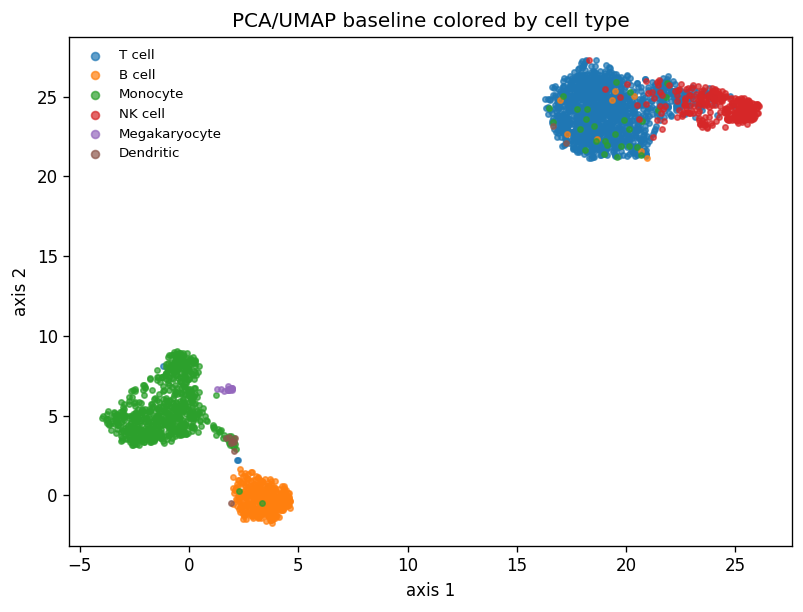

In [24]:
umap_xy = adata_hvg.obsm["X_umap"]
ct_labels = adata.obs["cell_type"].to_numpy() if "cell_type" in adata.obs else adata.obs.iloc[:, 0].to_numpy()
plot_2d(umap_xy, ct_labels, "PCA/UMAP baseline colored by cell type")


**주의:** UMAP은 visualization이지 annotation의 정답지가 아닙니다. 

가깝다고 같은 cell type인 것도, 멀다고 다른 기능인 것도 아닙니다. 

baseline이 이미 cell type을 잘 나눈다면 Geneformer 임베딩이 무엇을 더하는지 더 엄격하게 물어야 합니다.

### cell embedding이란

cell embedding은 세포 상태를 요약한 고정 길이 벡터입니다(Geneformer는 256차원). 가까운 두 세포는 상태가 비슷해 거리·군집·분류가 의미를 가집니다.

- PCA는 이 데이터에서 학습하지만, Geneformer는 3천만 세포로 미리 학습합니다.
- PCA는 선형 축이지만, Geneformer는 attention으로 gene 사이 문맥을 반영합니다.

**핵심:** PCA는 이 데이터의 분산 방향, Geneformer embedding은 대규모 사전학습으로 만든 표현입니다.

## 5. 실제 Geneformer 세포 임베딩

Geneformer는 약 30M human single-cell transcriptome으로 학습해, rank-ordered gene sequence를 받아 256차원 임베딩을 만듭니다. 

cell type별로 균형 있게 `N_CELLS_EMBED`개를 추립니다.

**주의:** `N_CELLS_EMBED`(=600)는 상한입니다. 희귀 세포(Dendritic, Megakaryocyte)가 부족하면 실제 임베딩 세포 수는 600보다 작을 수 있습니다.

In [25]:
ct_arr = adata.obs["cell_type"].to_numpy()
n_each = max(1, N_CELLS_EMBED // len(pd.unique(ct_arr)))
sub_idx = []
for ct in pd.unique(ct_arr):
    pos = np.where(ct_arr == ct)[0]
    sub_idx.extend(rng.choice(pos, size=min(len(pos), n_each), replace=False))
sub_idx = np.array(sorted(sub_idx))
sub_obs = adata.obs.iloc[sub_idx].reset_index(drop=True)
symbols = np.asarray(adata.var_names)
Mc = counts_matrix()
count_rows = [dense_row(Mc, i) for i in sub_idx]
print("임베딩 대상 세포:", len(sub_idx))


임베딩 대상 세포: 425


아래 셀이 기본 경로, 즉 실제 Geneformer로 임베딩을 뽑는 부분입니다. 

gene dictionary 3개와 Geneformer V1-10M을 내려받아 토큰화·forward pass·mean-pooling으로 세포당 256차원 벡터를 만들고, 실패하면 다음 셀 fallback으로 넘어갑니다.

**주의:** 다운로드와 forward pass로 수 분 걸릴 수 있고 진행 막대가 멈춘 듯 보여도 정상입니다. 로드 중 `pooler weights ... newly initialized` 경고는 pooler 대신 `last_hidden_state`를 직접 mean-pooling하므로 무시해도 됩니다. 출력의 `embedding source`가 'Geneformer ...'인지 'fallback ...'인지 확인합니다.

### 이 셀은 4단계를 한 셀에 합칩니다

1. 로드. gene dictionary 3개(token / median / name→id)와 Geneformer V1-10M을 내려받습니다.

2. 토큰화. raw count를 섹션 3의 정규화 순위(`count / gene median`)로 바꿔 상위 gene token id 시퀀스를 만듭니다.

3. forward pass. token 시퀀스로 `last_hidden_state`(token별 문맥 벡터)를 얻습니다.

4. mean-pooling. 그 벡터를 padding 제외 평균 내어 세포당 256차원 벡터로 만듭니다.


**핵심:** 네 단계로 세포당 256차원 임베딩을 만듭니다.

In [26]:
cell_emb = None
embedding_source = None
if USE_GENEFORMER:
    try:
        import pickle
        from huggingface_hub import hf_hub_download
        from transformers import AutoModel
        def _load_pkl(fn):
            return pickle.load(open(hf_hub_download(MODEL_REPO, fn), "rb"))
        token_dict  = _load_pkl("geneformer/gene_dictionaries_30m/token_dictionary_gc30M.pkl")
        median_dict = _load_pkl("geneformer/gene_dictionaries_30m/gene_median_dictionary_gc30M.pkl")
        name_id     = _load_pkl("geneformer/gene_dictionaries_30m/gene_name_id_dict_gc30M.pkl")
        gf_model = AutoModel.from_pretrained(MODEL_REPO, subfolder=MODEL_SUBFOLDER).to(device).eval()

        def tokenize_cell(counts, syms, max_len=2048):
            toks, vals = [], []
            for sym, v in zip(syms, counts):
                if v <= 0:
                    continue
                ens = name_id.get(sym)
                if ens is None or ens not in median_dict or ens not in token_dict:
                    continue
                toks.append(token_dict[ens]); vals.append(v / median_dict[ens])
            order = np.argsort(vals)[::-1][:max_len]
            return [toks[i] for i in order]

        def geneformer_embed(rows, syms, batch_size=16):
            pad = token_dict.get("<pad>", 0); out = []
            ids_all = [tokenize_cell(r, syms) or [pad] for r in rows]
            for s in range(0, len(ids_all), batch_size):
                chunk = ids_all[s:s+batch_size]; ml = max(len(x) for x in chunk)
                ids = torch.tensor([x + [pad]*(ml-len(x)) for x in chunk], device=device)
                attn = (ids != pad).long()
                with torch.no_grad():
                    h = gf_model(input_ids=ids, attention_mask=attn).last_hidden_state
                m = attn.unsqueeze(-1).to(h.dtype)
                out.append(((h*m).sum(1)/m.sum(1).clamp(min=1)).float().cpu().numpy())
            return np.concatenate(out, 0)

        cell_emb = geneformer_embed(count_rows, symbols)
        embedding_source = "Geneformer V1-10M mean-pooled last hidden state"
        print(f"Geneformer embedding: {cell_emb.shape} | device: {device}")
        if device.type == "cuda":
            print(f"GPU memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    except Exception as exc:
        print("Geneformer embedding 실패. fallback으로 전환합니다.")
        print(type(exc).__name__, exc)


Some weights of BertModel were not initialized from the model checkpoint at ctheodoris/Geneformer and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Geneformer embedding: (425, 256) | device: cpu


다음은 fallback 경로입니다. `cell_emb`가 아직 `None`이면(Geneformer를 끄거나 로드가 실패한 경우) 앞에서 계산한 PCA 좌표를 임베딩으로 씁니다. 

추려 둔 세포의 PCA representation을 가져와 같은 분석을 이어 갑니다. 이렇게 하면 모델 다운로드가 막혀도 시각화와 nearest neighbor 흐름이 끊기지 않습니다.

In [27]:
if cell_emb is None:
    cell_emb = np.asarray(adata_hvg.obsm["X_pca"])[sub_idx]
    embedding_source = "fallback: PCA(30) baseline"
print("embedding source:", embedding_source, "| shape:", cell_emb.shape)


embedding source: Geneformer V1-10M mean-pooled last hidden state | shape: (425, 256)


## 6. 세포 임베딩 시각화

임베딩을 2차원으로 투영해 그립니다. Geneformer 임베딩은 256차원이므로 PCA로 2차원으로 줄여 산점도를 그립니다. 

cell type 색으로 칠해 모델 임베딩이 면역세포 종류를 어떻게 배치하는지 봅니다. 

baseline UMAP과 비교하면 같은 세포를 두 표현이 어떻게 다르게 보는지 감을 잡을 수 있습니다.

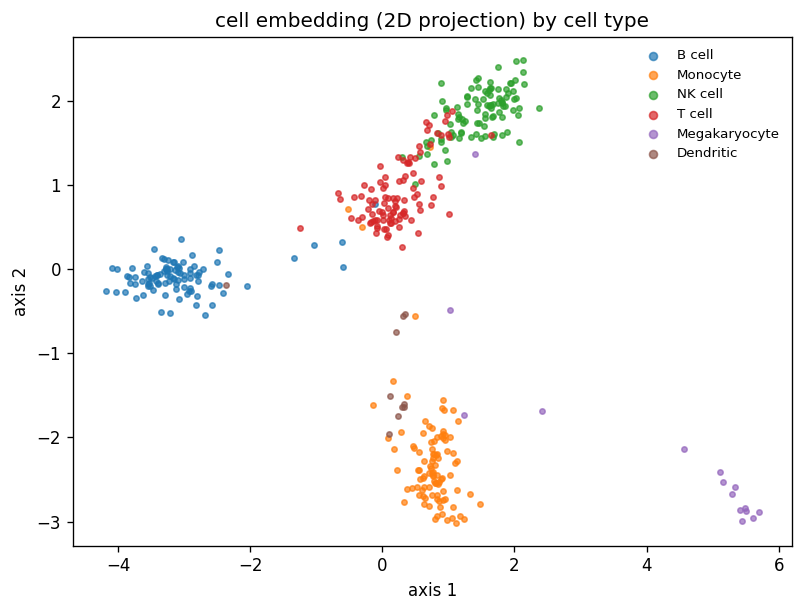

In [28]:
emb_xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(cell_emb)
plot_2d(emb_xy, sub_obs["cell_type"].to_numpy(), "cell embedding (2D projection) by cell type")


## 7. 비슷한 세포 찾기

임베딩 공간에서 각 세포의 가장 닮은 이웃을 찾습니다. 

`cosine_similarity`로 유사도를 구하고 대각선을 음의 무한대로 채워 자기 자신을 제외한 뒤, query와 nearest 세포의 cell type을 비교합니다.

**참고:** cosine similarity는 각도 기반으로 1이면 같은 방향, 0이면 직교, -1이면 반대입니다.

In [64]:
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(cell_emb)
np.fill_diagonal(sim, -np.inf)
nn = sim.argmax(axis=1)
neighbor_df = pd.DataFrame({
    "query_type": sub_obs["cell_type"].to_numpy(),
    "nearest_type": sub_obs["cell_type"].to_numpy()[nn],
    "cosine_similarity": np.round(sim[np.arange(len(nn)), nn], 3),
})
agree = float((neighbor_df["query_type"] == neighbor_df["nearest_type"]).mean())
print(f"nearest neighbor가 같은 cell type인 비율: {agree:.2f}")
disagree = neighbor_df[neighbor_df["query_type"] != neighbor_df["nearest_type"]]
print(f"다른 cell type이 가장 가까운 세포: {len(disagree)}개 (아래는 그 예시")
display(disagree.head(8) if len(disagree) else neighbor_df.head(8))


nearest neighbor가 같은 cell type인 비율: 0.91
다른 cell type이 가장 가까운 세포: 40개 (아래는 그 예시


,query_type,nearest_type,cosine_similarity
10,NK cell,T cell,0.971
27,NK cell,T cell,0.984
28,T cell,NK cell,0.989
35,T cell,NK cell,0.983
36,Megakaryocyte,Monocyte,0.962
39,Megakaryocyte,Monocyte,0.928
58,B cell,T cell,0.987
65,NK cell,T cell,0.984


nearest neighbor가 같은 cell type인 비율이 높을수록 임베딩이 cell type 구조를 잘 보존합니다. 

- 예시) T와 NK는 둘다 Lymphocyte로 similarity가 높고, megakaryocyte와 monocyte는 그렇지 않습니다.

다만 이 가까움은 표현 안의 유사성이지 인과적 동일성이 아닙니다. 

다른 type이 가까운 행은 marker 겹침, doublet, 중간 상태일 수 있습니다.

**참고:** 위 표는 일부러 불일치 세포만 보여 줍니다.

## 8. Supervised probing: 임베딩에 정보가 있는가

probing은 임베딩을 고정한 채 작은 분류기만 학습해 임베딩이 cell type 정보를 담는지 평가합니다. 

reference (train) 임베딩으로 logistic regression을 학습해 query(test) 정확도를 봅니다.

**주의:** 여기서는 가장 단순한 무작위 cell split을 씁니다. 슬라이드 p.40과 마무리 checklist의 donor/batch/tissue holdout이 실제로는 필요합니다. 또 pseudo-label과 임베딩이 같은 marker 발현에서 나와 검증이 부분적으로 순환적이므로, 점수는 정보 유무 정도로만 읽습니다.

In [31]:
y = sub_obs["cell_type"].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(cell_emb, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print("reference:", Xtr.shape[0], "| query:", Xte.shape[0])


reference: 297 | query: 128


reference 임베딩으로 logistic regression probe를 학습합니다. 

`class_weight="balanced"`는 cell type 불균형을 보정하고, `classification_report`로 type별 precision, recall, f1을 봅니다. 

점수가 높아도 pseudo-label이 marker 리스트에 위해 만들어진 라벨이기에, 생물학적 정확성을 증명하지는 않을 수 있습니다.

**출력 읽기** support가 작은 type(예: Megakaryocyte)의 완벽 점수는 세포 하나만 틀려도 흔들리므로 과신하지 않습니다.

In [32]:
probe = LogisticRegression(max_iter=2000, class_weight="balanced")
probe.fit(Xtr, ytr)
pred = probe.predict(Xte)
print(classification_report(yte, pred, zero_division=0))


               precision    recall  f1-score   support

       B cell       0.97      1.00      0.98        30
    Dendritic       0.75      1.00      0.86         3
Megakaryocyte       1.00      0.80      0.89         5
     Monocyte       1.00      0.97      0.98        30
      NK cell       0.96      0.87      0.91        30
       T cell       0.88      0.97      0.92        30

     accuracy                           0.95       128
    macro avg       0.93      0.93      0.92       128
 weighted avg       0.95      0.95      0.95       128



행렬로 어떤 cell type을 어디로 헷갈렸는지 봅니다. 대각선이 맞게 분류한 경우이고, 대각선 밖 숫자가 오답입니다. 

면역세포 중 marker가 일부 겹치는 종류 (예: T cell과 NK cell)가 서로 헷갈리는지, 

드문 cell type이 흔한 type으로 흡수되는지를 보는 것이 점수 하나보다 유용할 수 있습니다.

In [33]:
labels_sorted = sorted(pd.unique(y))
cm = confusion_matrix(yte, pred, labels=labels_sorted)
display(pd.DataFrame(cm, index=[f"true {x}" for x in labels_sorted], columns=[f"pred {x}" for x in labels_sorted]))


,pred B cell,pred Dendritic,pred Megakaryocyte,pred Monocyte,pred NK cell,pred T cell
true B cell,30,0,0,0,0,0
true Dendritic,0,3,0,0,0,0
true Megakaryocyte,0,0,4,0,1,0
true Monocyte,0,1,0,29,0,0
true NK cell,0,0,0,0,26,4
true T cell,1,0,0,0,0,29


## 9. Batch integration: 서로 다른 두 데이터셋

앞 절까지는 pbmc3k, 데이터셋 A만 다뤘습니다. 

여기서는 프로토콜이 다른 데이터셋 B (pbmc_1k_v3(10x v3))를 A와 함께 써서 실제 technical batch effect를 확인합니다.

- PCA baseline에서 두 batch가 갈라지는지.
- Geneformer zero-shot embedding이 두 batch를 섞는지.
- Harmony 같은 전용 도구와 비교.

**핵심:** Geneformer의 rank 인코딩은 depth 차이에 강건하지만 batch를 완전히 제거한다는 보장은 없으므로, 제거 정도를 지표로 확인합니다.

In [34]:
# 두 번째 batch 데이터셋(pbmc_1k_v3, 10x v3) 다운로드 + QC + 주석
import os, urllib.request
import anndata as ad
_URL = "https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_filtered_feature_bc_matrix.h5"
_FN = "pbmc_1k_v3.h5"
def _annotate(a):
    pp = a.copy(); sc.pp.normalize_total(pp, target_sum=1e4); sc.pp.log1p(pp)
    sco = pd.DataFrame(index=a.obs_names)
    for ct, ms in MARKER_SETS.items():
        pr = [g for g in ms if g in pp.var_names]
        if pr:
            X = pp[:, pr].X
            sco[ct] = np.asarray(X.mean(axis=1)).ravel()
    a.obs["cell_type"] = sco.idxmax(axis=1).values
    return a
_brng = np.random.default_rng(RANDOM_STATE)   # 독립 rng (global rng 안 건드림 → 뒤 perturbation 결과 불변)
def _subs(a, n):
    idx = _brng.choice(a.n_obs, size=min(n, a.n_obs), replace=False)
    return a[idx].copy()

HAS_BATCH2 = False
try:
    if not os.path.exists(_FN):
        print("pbmc_1k_v3 다운로드 중 (~5MB)...")
        # 10x Cloudflare CDN은 기본 urllib UA를 403으로 막으므로 브라우저 UA 헤더 필요
        _req = urllib.request.Request(_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(_req, timeout=120) as _r, open(_FN, "wb") as _f:
            _f.write(_r.read())
    b2 = sc.read_10x_h5(_FN); b2.var_names_make_unique()
    sc.pp.filter_cells(b2, min_genes=200); sc.pp.filter_genes(b2, min_cells=3)
    b2.layers["counts"] = b2.X.copy(); _annotate(b2)

    b1 = adata.copy()                     # pbmc3k (raw counts in layers["counts"], gene_ids in var)
    if "cell_type" not in b1.obs: _annotate(b1)
    b1.obs["batch"] = "Sample A"; b2.obs["batch"] = "Sample B"
    N_PER = 350
    s1, s2 = _subs(b1, N_PER), _subs(b2, N_PER)
    # Geneformer는 세포별 독립 토큰화 → 배치가 유전자를 공유할 필요 없음. symbol 보존.
    s1.var["symbol"] = s1.var_names.astype(str); s2.var["symbol"] = s2.var_names.astype(str)
    gf1 = (s1.layers["counts"], np.asarray(s1.var["symbol"]))
    gf2 = (s2.layers["counts"], np.asarray(s2.var["symbol"]))
    # PCA/Harmony baseline은 Ensembl ID로 join (pbmc3k=hg19, v3=GRCh38 → symbol 말고 gene_ids)
    for a in (s1, s2):
        a.var_names = a.var["gene_ids"].astype(str).values; a.var_names_make_unique()
    comb = ad.concat([s1, s2], join="inner")
    comb.layers["counts"] = comb.X.copy()
    HAS_BATCH2 = True
    print("combined:", comb.shape, "| batch:", comb.obs["batch"].value_counts().to_dict())
    display(pd.crosstab(comb.obs["batch"], comb.obs["cell_type"]))
except Exception as e:
    print("batch2 로드 실패 — batch integration 데모를 건너뜁니다:", type(e).__name__, e)


combined: (700, 12856) | batch: {'Sample A': 350, 'Sample B': 350}


cell_type,B cell,Dendritic,Megakaryocyte,Monocyte,NK cell,T cell
batch,,,,,,
Sample A,53,1,1,94,30,171
Sample B,59,4,4,100,27,156


먼저 baseline입니다. 두 데이터셋을 합쳐 표준 전처리(정규화·HVG·PCA)한 뒤, 같은 좌표를 batch 색과 cell type 색으로 봅니다. 

2D 좌표는 UMAP으로 그리고, silhouette 지표는 전체 차원에서 계산합니다. batch가 갈라져 보이면 실제 batch effect가 있는 것입니다.

In [35]:
# baseline: 합친 데이터에 표준 PCA. 계산만 하고(임베딩+silhouette 저장), 시각화는 뒤 셀에서 한꺼번에.
from sklearn.metrics import silhouette_score as _ss
def _sil(X, key):
    return round(float(_ss(X, comb.obs[key])), 3)
def _project2d(X):
    try:
        import umap
        return umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X), "UMAP"
    except Exception:
        return PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X), "PCA(2)"
results, sil_tab = {}, {}
def run_method(emb, name):        # 계산만: 임베딩과 silhouette 저장 (UMAP은 뒤 셀에서 한꺼번에)
    results[name] = emb
    sil_tab[name] = {"batch_sil (↓좋음)": _sil(emb, "batch"), "celltype_sil (유지좋음)": _sil(emb, "cell_type")}

if HAS_BATCH2:
    cp = comb.copy(); sc.pp.normalize_total(cp, target_sum=1e4); sc.pp.log1p(cp)
    sc.pp.highly_variable_genes(cp, n_top_genes=2000)
    cp = cp[:, cp.var.highly_variable].copy(); sc.pp.scale(cp, max_value=10)
    X_pca = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(cp.X)
    run_method(X_pca, "PCA baseline")

이제 Geneformer zero-shot 임베딩입니다. 두 batch를 함께 토큰화 및 임베딩 해 합친 뒤 batch 색과 cell type 색으로 봅니다.

In [36]:
# Geneformer 임베딩 (배치별 독립) → batch + cell type 색
if HAS_BATCH2:
    if str(embedding_source).startswith("Geneformer"):
        gf_emb = np.vstack([geneformer_embed(list(gf1[0].toarray() if hasattr(gf1[0], "toarray") else gf1[0]), gf1[1]),
                            geneformer_embed(list(gf2[0].toarray() if hasattr(gf2[0], "toarray") else gf2[0]), gf2[1])])
        _tag = "Geneformer (zero-shot)"
    else:
        gf_emb = results["PCA baseline"]   # fallback: 실제 Geneformer 없음 → baseline로 대체 표시
        _tag = "Geneformer (fallback=baseline)"
    run_method(gf_emb, _tag)


전용 integration 도구 Harmony를 같은 데이터에 적용해, batch를 섞으면서 cell type을 보존하는지 봅니다.

In [37]:
# Harmony (전용 integration 도구) — 없으면 설치, 실패해도 계속
if HAS_BATCH2:
    try:
        try:
            import harmonypy
        except ImportError:
            import subprocess, sys; subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "harmonypy"]); import harmonypy
        _ho = harmonypy.run_harmony(results["PCA baseline"], comb.obs, ["batch"])
        _Z = np.asarray(_ho.Z_corr); results["Harmony"] = _Z if _Z.shape[0] == comb.n_obs else _Z.T
        run_method(results["Harmony"], "Harmony")
    except Exception as e:
        print("Harmony 건너뜀:", type(e).__name__, e)


2026-07-24 07:28:21,455 - harmonypy - INFO - Running Harmony
2026-07-24 07:28:21,456 - harmonypy - INFO -   Parameters:
2026-07-24 07:28:21,457 - harmonypy - INFO -     max_iter_harmony: 10
2026-07-24 07:28:21,457 - harmonypy - INFO -     max_iter_kmeans: 4
2026-07-24 07:28:21,458 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-07-24 07:28:21,458 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-07-24 07:28:21,459 - harmonypy - INFO -     nclust: 23
2026-07-24 07:28:21,459 - harmonypy - INFO -     block_size: 0.05
2026-07-24 07:28:21,460 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-07-24 07:28:21,461 - harmonypy - INFO -     theta: [2. 2.]
2026-07-24 07:28:21,462 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-07-24 07:28:21,462 - harmonypy - INFO -     verbose: True
2026-07-24 07:28:21,463 - harmonypy - INFO -     random_state: 0
2026-07-24 07:28:21,464 - harmonypy - INFO -   Data: 30 PCs × 700 cells
2026-07-24 07:28:21,464 - harmonypy - INFO -   Batch 

각 방법을 한 표로 비교합니다. 

batch_silhouette은 낮을수록 좋고, celltype_silhouette은 baseline 수준을 유지해야 좋습니다. 

batch만 낮추고 celltype이 무너지면 over-integration입니다.

**핵심:** 좋은 integration은 batch_silhouette을 낮추면서 celltype_silhouette을 지킵니다.

In [38]:
# 결과 요약 표 (먼저) — batch_sil 낮을수록 섞임 좋음 / celltype_sil 유지 좋음
if HAS_BATCH2 and sil_tab:
    display(pd.DataFrame(sil_tab).T)

,batch_sil (↓좋음),celltype_sil (유지좋음)
PCA baseline,0.110,0.244
Geneformer (zero-shot),0.163,0.271
Harmony,0.068,0.254


이제 세 방법의 2D 임베딩을 **한 그림에 나란히** 봅니다 (행=방법, 왼쪽 열=Sample 색, 오른쪽 열=cell type 색). 

왼쪽에서 Sample A·B가 **섞일수록**, 오른쪽에서 cell type이 **뭉칠수록** 통합이 잘 된 것입니다. 색은 패널마다 고정입니다.

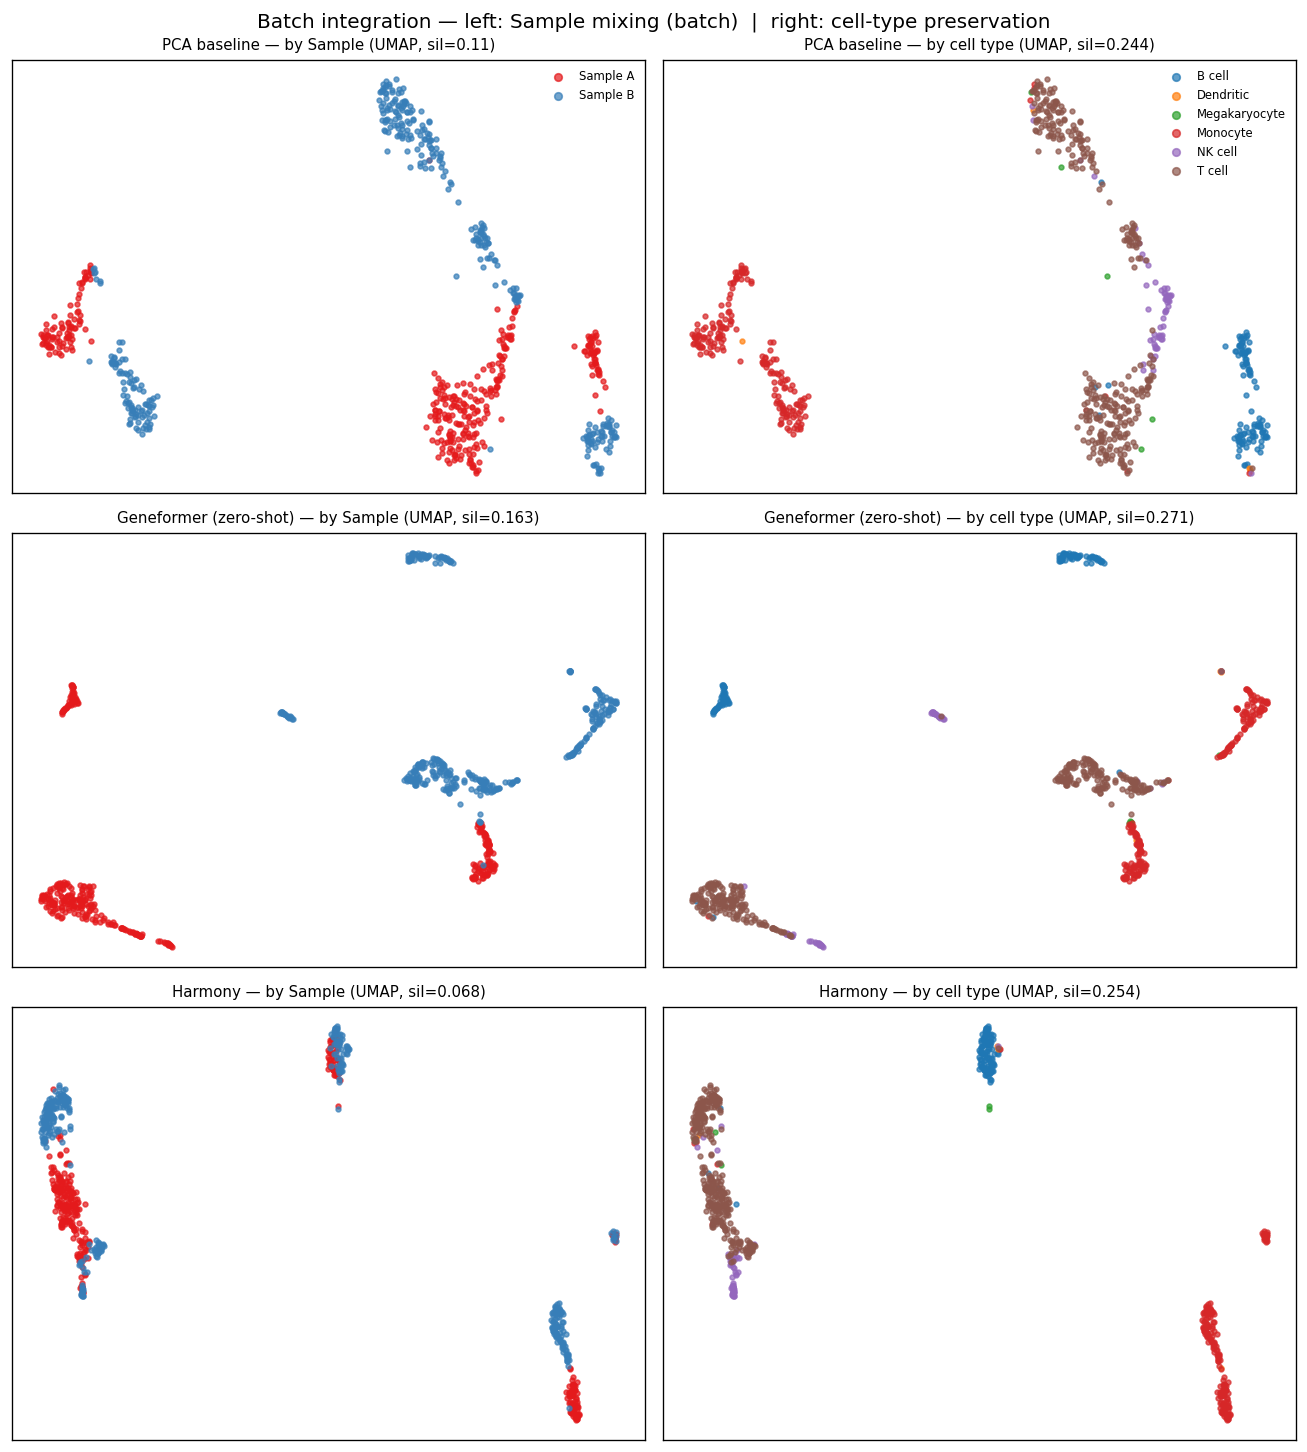

In [39]:
# 모든 방법의 UMAP을 한 셀에 grid로 (계산은 위에서 끝났고 여기선 2D 투영+그리기만)
if HAS_BATCH2 and results:
    _bat = comb.obs["batch"].to_numpy(); _cty = comb.obs["cell_type"].to_numpy()
    _bpal = {b: c for b, c in zip(sorted(pd.unique(_bat)), plt.cm.Set1.colors)}
    _cpal = {t: c for t, c in zip(sorted(pd.unique(_cty)), plt.cm.tab10.colors)}
    _methods = list(results)
    fig, axes = plt.subplots(len(_methods), 2, figsize=(11, 4.1*len(_methods)), squeeze=False)
    for _r, _name in enumerate(_methods):
        _xy, _proj = _project2d(results[_name])
        for _c, (_labs, _pal, _ttl) in enumerate([(_bat, _bpal, "by Sample"), (_cty, _cpal, "by cell type")]):
            _ax = axes[_r][_c]
            for _lab in sorted(pd.unique(_labs)):
                _m = _labs == _lab
                _ax.scatter(_xy[_m, 0], _xy[_m, 1], s=8, alpha=0.7, color=_pal[_lab], label=str(_lab))
            _sk = 'batch' if _c == 0 else 'cell_type'
            _ax.set_title(f"{_name} — {_ttl} ({_proj}, sil={_sil(results[_name], _sk)})", fontsize=9)
            _ax.set_xticks([]); _ax.set_yticks([])
            if _r == 0: _ax.legend(frameon=False, fontsize=7, markerscale=1.6, loc="best")
    fig.suptitle("Batch integration — left: Sample mixing (batch)  |  right: cell-type preservation", fontsize=12)
    plt.tight_layout(); plt.show()

이 실습을 정리합니다.

- baseline에는 실제 A-B batch가 있습니다 (batch_sil > 0). 
- Geneformer zero-shot은 rank 인코딩 덕에 batch에 부분적으로 강건하지만 완전한 통합은 보장하지 못합니다.
- Harmony는 batch를 더 낮추면서 cell type을 보존해, 전용 도구가 왜 필요한지 보여 줍니다.
- 하지만 원래 학습 목적에 맞게, Geneformer가 cell type 보존력이 제일 좋습니다.

**핵심:** foundation model 임베딩도 zero-shot으로는 batch를 완전히 없애지 못하므로, 실제 데이터에서는 batch와 biology 지표를 함께 확인합니다.

### Geneformer fine-tuning: 독립 데이터로 학습하면 통합·분류가 개선되나?

fine-tuning의 batch 통합 효과를 정직하게 보려면 **학습 데이터가 평가 batch에 들어가면 안 됩니다**(안 그러면 memorization). 그래서 역할을 나눕니다:

- **학습 = Data C** — zero-shot probe(LR)와 fine-tuning 둘 다 C로 학습.
- **평가 = Data A+B** — 통합 품질 (배치·셀타입)과 셀타입 분류성능(AUROC·accuracy)를 확인. (A·B는 한 번도 학습에 쓰이지 않음.)

In [40]:
# fine-tune 학습셋 C = 5k PBMC (독립). 평가셋 = held-out A+B (comb, v1+v3, §9와 동일).
RUN_FINETUNE = True
if RUN_FINETUNE and HAS_BATCH2 and str(embedding_source).startswith("Geneformer"):
    import os, urllib.request, time, random, torch, scipy.sparse as sp
    from transformers import AutoModelForSequenceClassification
    from sklearn.preprocessing import LabelEncoder
    random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE); torch.cuda.manual_seed_all(RANDOM_STATE)
    _URLC, _FNC = "https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_pbmc_v3/5k_pbmc_v3_filtered_feature_bc_matrix.h5", "5k_pbmc_v3.h5"
    if not os.path.exists(_FNC):
        print("C(5k) 다운로드 중 (~18MB)...")
        _rq = urllib.request.Request(_URLC, headers={"User-Agent": "Mozilla/5.0"})  # 10x CDN UA 우회
        with urllib.request.urlopen(_rq, timeout=180) as _r, open(_FNC, "wb") as _f: _f.write(_r.read())
    Cds = sc.read_10x_h5(_FNC); Cds.var_names_make_unique()
    sc.pp.filter_cells(Cds, min_genes=200); sc.pp.filter_genes(Cds, min_cells=3)
    Cds.layers["counts"] = Cds.X.copy(); _annotate(Cds)
    Cds = Cds[np.random.default_rng(RANDOM_STATE).choice(Cds.n_obs, min(800, Cds.n_obs), replace=False)].copy()
    print("C(train, 5k v3):", Cds.shape, "|", Cds.obs["cell_type"].value_counts().to_dict())

    _le = LabelEncoder().fit(np.array(list(MARKER_SETS.keys())))
    _PAD, _BS = token_dict.get("<pad>", 0), 16
    def _rw(X, i):
        r = X[i]; return np.asarray(r.todense()).ravel() if sp.issparse(r) else np.asarray(r).ravel()
    def _tk(counts, ens, ml=1024):
        nz = np.where(counts > 0)[0]
        pr = [(token_dict[ens[j]], counts[j]/median_dict[ens[j]]) for j in nz if ens[j] in token_dict and ens[j] in median_dict]
        pr.sort(key=lambda p: p[1], reverse=True); return [t for t, _ in pr[:ml]]
    def _btc(seqs, idxs, ys=None):
        ss = [seqs[i] or [_PAD] for i in idxs]; ml = max(len(x) for x in ss)
        ids = torch.tensor([x + [_PAD]*(ml-len(x)) for x in ss], device=device, dtype=torch.long)
        lab = torch.tensor([ys[i] for i in idxs], device=device) if ys is not None else None
        return ids, (ids != _PAD).long(), lab
    def _emb(model, seqs, is_cls):
        out = []
        with torch.no_grad():
            for _s in range(0, len(seqs), _BS):
                ids, att, _ = _btc(seqs, range(_s, min(_s+_BS, len(seqs))))
                h = (model(input_ids=ids, attention_mask=att, output_hidden_states=True).hidden_states[-1] if is_cls
                     else model(input_ids=ids, attention_mask=att).last_hidden_state)
                m = att.unsqueeze(-1).float(); out.append(((h*m).sum(1)/m.sum(1).clamp(min=1)).cpu().numpy())
        return np.concatenate(out, 0)
    _ensC = np.asarray(Cds.var["gene_ids"].astype(str)); _ensAB = np.asarray(comb.var_names)
    _tC = [_tk(_rw(Cds.layers["counts"], i), _ensC) for i in range(Cds.n_obs)]
    _tAB = [_tk(_rw(comb.layers["counts"], i), _ensAB) for i in range(comb.n_obs)]
    _yC = _le.transform(Cds.obs["cell_type"].to_numpy())
    print(f"토큰 커버리지  C / A+B : {np.mean([len(t)>0 for t in _tC]):.0%} / {np.mean([len(t)>0 for t in _tAB]):.0%}")

    _fm = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO, subfolder=MODEL_SUBFOLDER, num_labels=len(_le.classes_)).to(device)
    _opt = torch.optim.AdamW(_fm.parameters(), lr=5e-5); _idx = np.arange(len(_tC)); _t0 = time.time()
    for _ep in range(3):
        _fm.train(); np.random.shuffle(_idx)
        for _s in range(0, len(_idx), _BS):
            ids, att, lab = _btc(_tC, _idx[_s:_s+_BS], _yC)
            o = _fm(input_ids=ids, attention_mask=att, labels=lab); o.loss.backward(); _opt.step(); _opt.zero_grad()
    _fm.eval(); print(f"[TIME] fine-tune on C(5k, {len(_tC)} cells): {time.time()-_t0:.1f}s")
else:
    print("fine-tuning은 실제 Geneformer(GPU) + HAS_BATCH2 경로에서만 실행됩니다.")


C(train, 5k v3): (800, 18791) | {'T cell': 441, 'Monocyte': 181, 'B cell': 86, 'NK cell': 83, 'Dendritic': 5, 'Megakaryocyte': 4}
토큰 커버리지  C / A+B : 100% / 100%


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ctheodoris/Geneformer and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[TIME] fine-tune on C(5k, 800 cells): 415.7s


위 셀에서 독립 데이터 **C** 로 fine-tune한 모델을, 이제 한 번도 보지 않은 **A+B**에 적용해 통합(batch_sil·celltype_sil)과 분류(AUROC·accuracy, A/B 분해)를 평가합니다.

In [41]:
# 평가: held-out A+B에서 통합(batch_sil·celltype_sil) + 분류(accuracy·AUROC, Sample A/B 분해) — 표로 출력
if RUN_FINETUNE and "_fm" in globals() and HAS_BATCH2 and str(embedding_source).startswith("Geneformer"):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import accuracy_score, roc_auc_score, silhouette_score
    def _proba(model, seqs):
        P = []
        with torch.no_grad():
            for _s in range(0, len(seqs), _BS):
                ids, att, _ = _btc(seqs, range(_s, min(_s+_BS, len(seqs))))
                P.append(torch.softmax(model(input_ids=ids, attention_mask=att).logits, -1).cpu().numpy())
        return np.concatenate(P, 0)
    def _auroc(y, P):
        cls = np.unique(y)
        if len(cls) < 2: return float("nan")
        try:
            Yb = label_binarize(y, classes=cls); Pp = P[:, cls]; Pp = Pp/Pp.sum(1, keepdims=True).clip(1e-9)
            return round(float(roc_auc_score(Yb, Pp, average="macro")), 3)
        except Exception: return float("nan")
    _sl = lambda e, l: round(float(silhouette_score(e, l)), 3) if len(np.unique(l)) >= 2 else float("nan")

    _zsAB, _ftAB = _emb(gf_model, _tAB, False), _emb(_fm, _tAB, True)
    _yAB = _le.transform(comb.obs["cell_type"].to_numpy()); _bAB = comb.obs["batch"].to_numpy()

    # (1) 통합 표
    _int = {"Geneformer zero-shot":  {"batch_sil (↓)": _sl(_zsAB, _bAB), "celltype_sil (↑)": _sl(_zsAB, _yAB)},
            "Geneformer fine-tuned": {"batch_sil (↓)": _sl(_ftAB, _bAB), "celltype_sil (↑)": _sl(_ftAB, _yAB)}}
    if "Harmony" in results:
        _int["Harmony (참조)"] = {"batch_sil (↓)": _sil(results["Harmony"], "batch"), "celltype_sil (↑)": _sil(results["Harmony"], "cell_type")}
    print("통합 (held-out A+B):"); display(pd.DataFrame(_int).T)

    # (2) 분류 표: C로 학습 → held-out 평가, zero-shot probe → fine-tuned
    _zsC = _emb(gf_model, _tC, False)
    _lr = LogisticRegression(max_iter=2000, class_weight="balanced").fit(_zsC, _yC)
    _pz, _pf = _lr.predict_proba(_zsAB), _proba(_fm, _tAB)
    _mA, _mB = _bAB == "Sample A", _bAB == "Sample B"
    _rows = []
    for _nm, _m in [("Sample A", _mA), ("Sample B", _mB), ("A+B", np.ones(len(_yAB), bool))]:
        _y = _yAB[_m]
        _rows.append({"set": _nm,
                      "accuracy (zs→ft)": f"{accuracy_score(_y, _pz[_m].argmax(1)):.3f}→{accuracy_score(_y, _pf[_m].argmax(1)):.3f}",
                      "AUROC (zs→ft)": f"{_auroc(_y, _pz[_m])}→{_auroc(_y, _pf[_m])}"})
    print("분류 (C로 학습 → held-out 평가):"); display(pd.DataFrame(_rows).set_index("set"))
    _ft_int = _ftAB
else:
    print("이 셀은 fine-tune 셀 실행 후 실제 Geneformer(GPU) 경로에서만 동작합니다.")

통합 (held-out A+B):


,batch_sil (↓),celltype_sil (↑)
Geneformer zero-shot,0.153,0.280
Geneformer fine-tuned,0.082,0.430
Harmony (참조),0.068,0.254


분류 (C로 학습 → held-out 평가):


,accuracy (zs→ft),AUROC (zs→ft)
set,,
Sample A,0.883→0.943,0.998→0.986
Sample B,0.954→0.940,0.933→0.966
A+B,0.919→0.941,0.94→0.964


## 10. In silico perturbation

한 세포에서 어떤 gene(program)을 지우고 다시 임베딩을 뽑아, 원래에서 얼마나 멀어졌는지 (1 − cosine = `effect_shift`)를 잽니다. 

많이 움직이면 그 표현이 그 gene에 의존한다는 뜻이고, 거의 안 움직이면 덜 중요하다는 뜻입니다. 

인과가 아니라 "그 program이 빠지면 표현이 얼마나 달라 보이나"입니다.

gene 하나만 빼면 세포당 수백 token 중 하나라 거의 안 움직이므로, 한 cell type을 정의하는 marker program 전체를 제거해 봅니다. 

Geneformer 경로면 토큰 제거 후 재임베딩, fallback이면 expression을 0으로 한 벡터 변화로 계산합니다.

In [42]:
GENEFORMER_OK = embedding_source.startswith("Geneformer")

# specificity는 정규화(log1p) 발현으로 계산 - annotation(섹션 4)과 같은 layer, library size 보정
def gene_mean_by_celltype(gene):
    if gene not in adata_pp.var_names:
        return None
    col = adata_pp[:, gene].X
    col = np.asarray(col.todense()).ravel() if sp.issparse(col) else np.asarray(col).ravel()
    return pd.Series(col).groupby(ct_arr).mean()

print("perturbation 경로:", "Geneformer 토큰 제거" if GENEFORMER_OK else "expression proxy")


perturbation 경로: Geneformer 토큰 제거


`perturb_shift`는 program의 marker gene을 하나라도 발현하는 세포를 골라, 해당하는 유전자의 값을 모두 제거한 뒤 임베딩 상에서의 이동 방향과 거리를 보여줍니다. 

이 값은 인과가 아니라 그 program이 빠지면 표현이 얼마나 달라 보이는가라서, 생물학 해석에는 주의를 요합니다.

In [43]:
def _emb_model(model, rows, is_cls):   # dataset A rows -> 임베딩 (encoder: last_hidden / classifier: hidden_states[-1])
    if not str(embedding_source).startswith("Geneformer"):
        def ev(r):
            s = r.sum(); return np.log1p(r / (s if s > 0 else 1) * 1e4)
        return np.array([ev(r) for r in rows])
    pad = token_dict.get("<pad>", 0); seqs = [tokenize_cell(r, symbols) or [pad] for r in rows]; out = []
    with torch.no_grad():
        for s in range(0, len(seqs), 16):
            ch = seqs[s:s+16]; ml = max(len(x) for x in ch)
            ids = torch.tensor([x + [pad]*(ml-len(x)) for x in ch], device=device, dtype=torch.long); att = (ids != pad).long()
            h = (model(input_ids=ids, attention_mask=att, output_hidden_states=True).hidden_states[-1] if is_cls
                 else model(input_ids=ids, attention_mask=att).last_hidden_state)
            m = att.unsqueeze(-1).float(); out.append(((h*m).sum(1)/m.sum(1).clamp(min=1)).cpu().numpy())
    return np.concatenate(out, 0)

def perturb_shift(genes, model=None, is_cls=False, n=24):
    if model is None and "gf_model" in globals(): model = gf_model
    gjs = [int(np.where(symbols == g)[0][0]) for g in genes if len(np.where(symbols == g)[0])]
    if not gjs:
        return np.nan, 0
    cand = [i for i in sub_idx if any(dense_row(Mc, i)[gj] > 0 for gj in gjs)]
    if not cand:
        return np.nan, 0
    cells_sel = list(np.random.default_rng(RANDOM_STATE).choice(cand, size=min(len(cand), n), replace=False))  # 결정적 선택 → 두 표가 같은 세포
    rows = [dense_row(Mc, i).astype(float) for i in cells_sel]
    rows_ko = [r.copy() for r in rows]
    for r in rows_ko:
        for gj in gjs:
            r[gj] = 0.0
    base, pert = _emb_model(model, rows, is_cls), _emb_model(model, rows_ko, is_cls)
    cos = (base * pert).sum(1) / (np.linalg.norm(base, axis=1) * np.linalg.norm(pert, axis=1) + 1e-8)
    return float(np.mean(1.0 - cos)), len(cells_sel)

교육용 program 후보 표를 만듭니다. 

각 후보는 cell type program(marker gene set)과 literature support로 구성되고, 마지막 housekeeping(GAPDH·ACTB·B2M)은 negative control입니다. 

`program_genes`가 이름을 marker 목록으로 바꾸고 각 program에 `perturb_shift`로 effect를 계산합니다.

**주의:** `literature_support`(0.2~0.9)는 실습용 임의 예시이며 실제 evidence(Open Targets, GWAS 등)가 아닙니다.

In [44]:
HK_GENES = ["GAPDH", "ACTB", "B2M"]
def program_genes(p):
    return MARKER_SETS.get(p, HK_GENES)

targets = pd.DataFrame([
    {"program": "T cell", "literature_support": 0.9},
    {"program": "B cell", "literature_support": 0.8},
    {"program": "Monocyte", "literature_support": 0.7},
    {"program": "NK cell", "literature_support": 0.6},
    {"program": "housekeeping", "literature_support": 0.2},
])
eff = [perturb_shift(program_genes(p)) for p in targets["program"]]
targets["effect_shift"] = [round(e[0], 4) if not np.isnan(e[0]) else np.nan for e in eff]
targets["n_cells"] = [e[1] for e in eff]
targets["genes"] = [", ".join(program_genes(p)) for p in targets["program"]]
display(targets[["program", "genes", "effect_shift", "n_cells", "literature_support"]])


,program,genes,effect_shift,n_cells,literature_support
0,T cell,"CD3D, CD3E, IL7R, TRAC",0.0009,24,0.9
1,B cell,"MS4A1, CD79A, CD79B, BANK1",0.0011,24,0.8
2,Monocyte,"LYZ, S100A8, S100A9, LST1",0.0017,24,0.7
3,NK cell,"NKG7, GNLY, KLRD1, PRF1",0.0018,24,0.6
4,housekeeping,"GAPDH, ACTB, B2M",0.0029,24,0.2


### effect_shift를 embedding에서 시각화

각 program을 발현하는 세포가 유전자 제거 후 embedding에서 얼마나 이동하는지 화살표로 그립니다.

- 왼쪽(단일 gene 제거)은 화살표가 거의 없습니다.
- 오른쪽(program 전체 제거)은 화살표가 뚜렷하게 길어집니다.

**핵심:** 단일 gene 제거는 embedding을 거의 바꾸지 않고 program 제거는 크게 바꾸므로, program 단위로 지웁니다.

**주의:** 2D 화살표 길이는 256차원 이동의 투영이며 정확한 크기는 표의 cosine 값입니다.

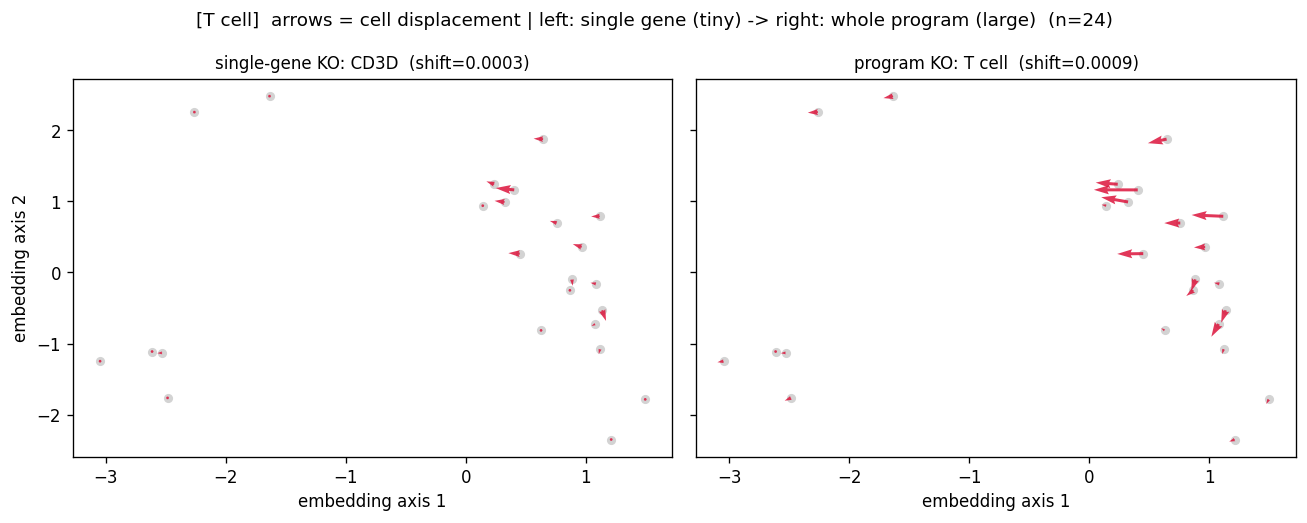

  [T cell] shift: single 'CD3D'=0.0003  vs  program=0.0009  (배율 3.0x)


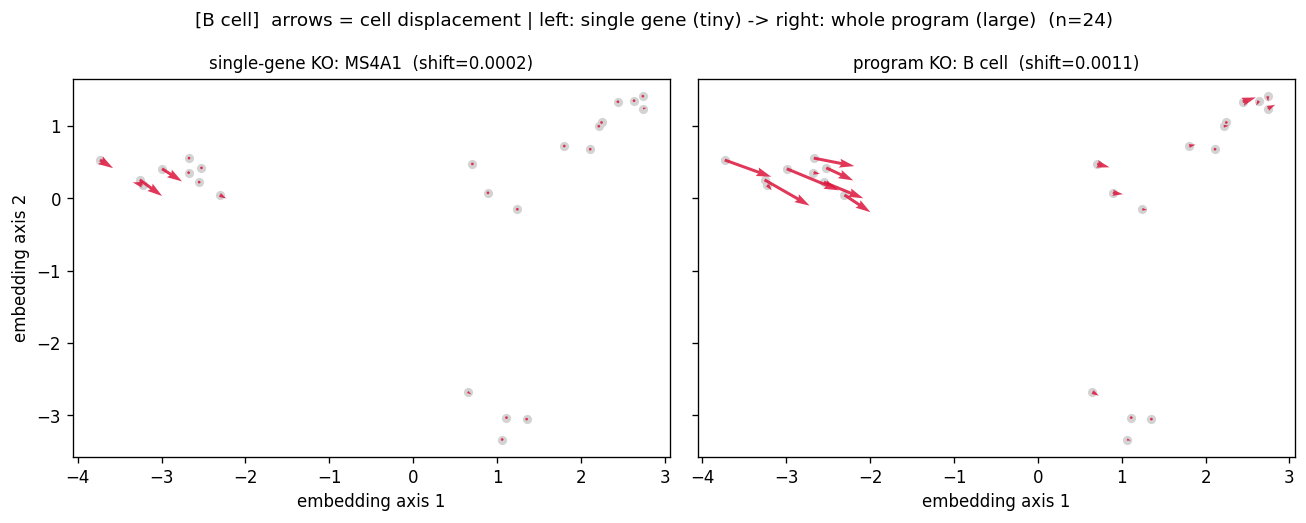

  [B cell] shift: single 'MS4A1'=0.0002  vs  program=0.0011  (배율 5.5x)


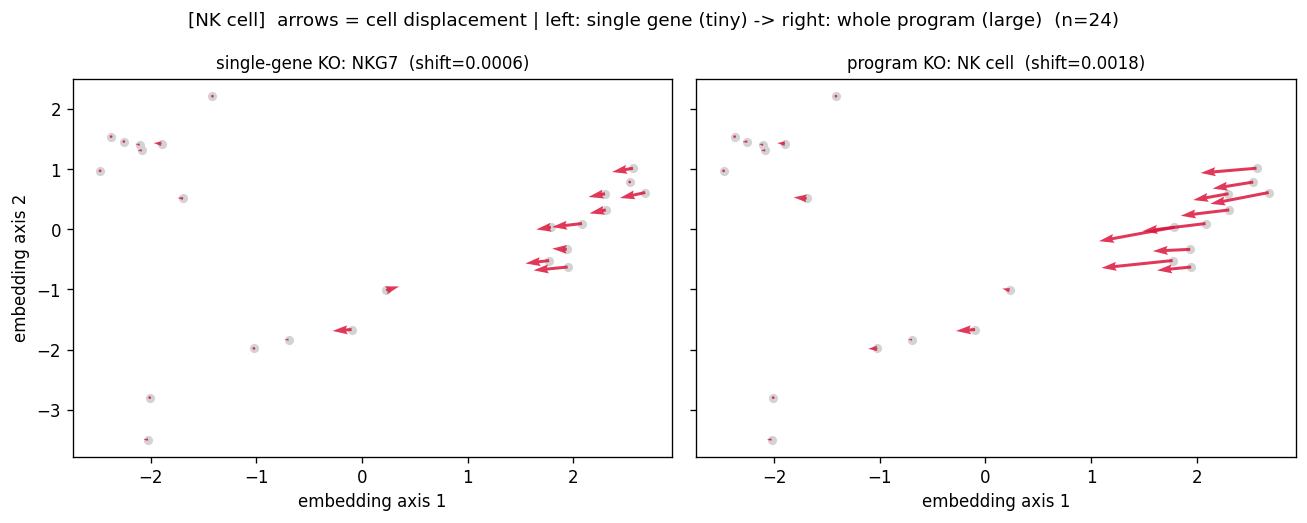

  [NK cell] shift: single 'NKG7'=0.0006  vs  program=0.0018  (배율 3.2x)


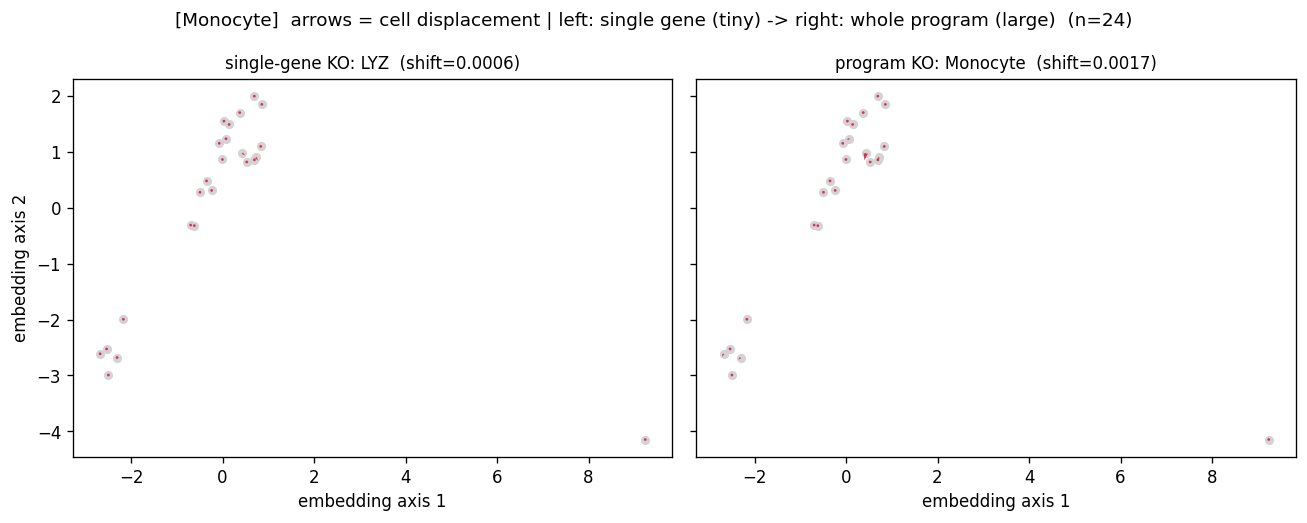

  [Monocyte] shift: single 'LYZ'=0.0006  vs  program=0.0017  (배율 2.7x)


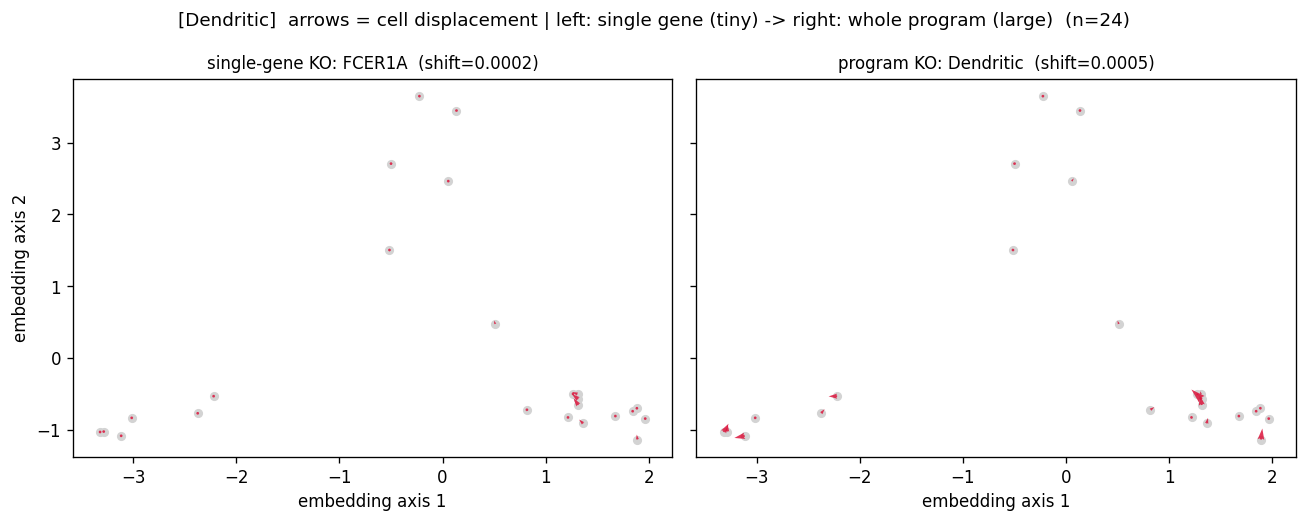

  [Dendritic] shift: single 'FCER1A'=0.0002  vs  program=0.0005  (배율 2.6x)


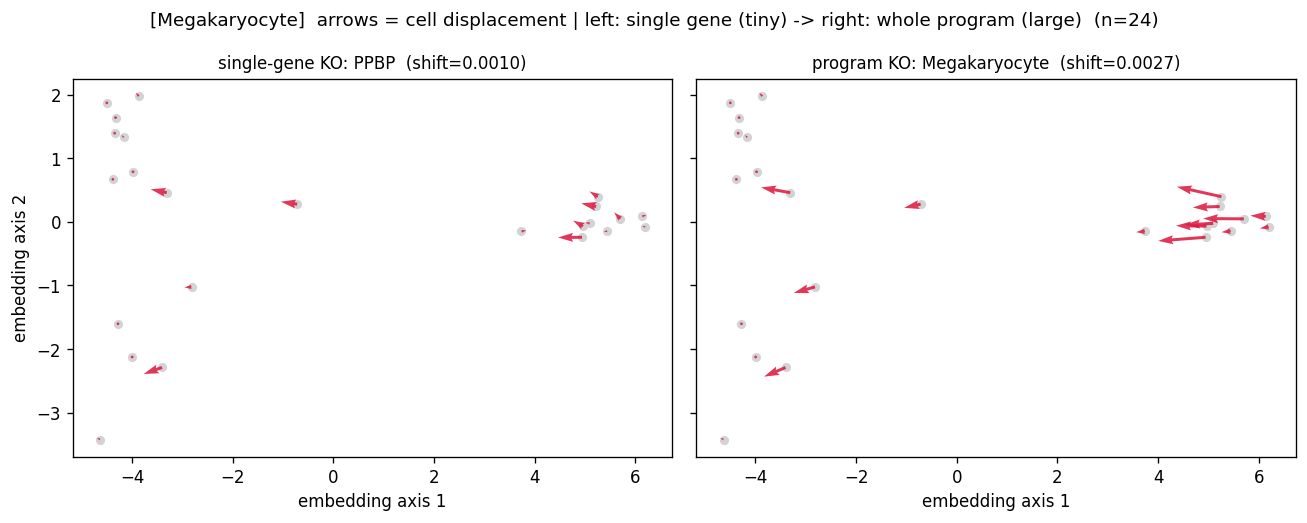

  [Megakaryocyte] shift: single 'PPBP'=0.0010  vs  program=0.0027  (배율 2.7x)


In [45]:
# in-silico perturbation을 임베딩 위에서 시각화: 모든 cell type program을 각각 (단일 gene vs program 전체)
def _embed_rows(rows):
    if str(embedding_source).startswith("Geneformer"):
        return geneformer_embed(rows, symbols)
    def ev(r):
        t = r.sum(); return np.log1p(r / (t if t > 0 else 1) * 1e4)
    return np.array([ev(r) for r in rows])
def _idx(g):
    hit = np.where(symbols == g)[0]
    return int(hit[0]) if len(hit) else None
def _ko(rows, genes):
    gj = [j for j in (_idx(g) for g in genes) if j is not None]
    out = [r.copy() for r in rows]
    for r in out:
        for j in gj:
            r[j] = 0.0
    return out
def _mcos(a, b):
    return float(np.mean(1 - (a * b).sum(1) / (np.linalg.norm(a, axis=1) * np.linalg.norm(b, axis=1) + 1e-8)))

def viz_program(prog, n=24, min_cells=8):
    genes = program_genes(prog); single = genes[0]
    gj_all = [j for j in (_idx(g) for g in genes) if j is not None]
    cand = [i for i in sub_idx if any(dense_row(Mc, i)[j] > 0 for j in gj_all)]
    if len(cand) < min_cells:
        print(f"[{prog}] 발현 세포 {len(cand)}개 — 너무 적어 생략"); return
    cells = list(np.random.default_rng(RANDOM_STATE).choice(cand, size=min(len(cand), n), replace=False))  # perturb_shift와 동일한 결정적 선택 → program shift가 위 effect_shift 표와 일치
    rows = [dense_row(Mc, i).astype(float) for i in cells]
    base = _embed_rows(rows); ko_s = _embed_rows(_ko(rows, [single])); ko_p = _embed_rows(_ko(rows, genes))
    pc = PCA(n_components=2, random_state=RANDOM_STATE).fit(base)
    b2, s2, p2 = pc.transform(base), pc.transform(ko_s), pc.transform(ko_p)
    ms, mp = _mcos(base, ko_s), _mcos(base, ko_p)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
    for ax, dst, ttl in [(axes[0], s2, f"single-gene KO: {single}  (shift={ms:.4f})"),
                         (axes[1], p2, f"program KO: {prog}  (shift={mp:.4f})")]:
        ax.scatter(b2[:, 0], b2[:, 1], s=20, c="lightgray", zorder=1)
        ax.quiver(b2[:, 0], b2[:, 1], dst[:, 0] - b2[:, 0], dst[:, 1] - b2[:, 1],
                  angles="xy", scale_units="xy", scale=1, color="crimson", width=0.005, alpha=0.85, zorder=2)
        ax.set_title(ttl, fontsize=10); ax.set_xlabel("embedding axis 1")
    axes[0].set_ylabel("embedding axis 2")
    fig.suptitle(f"[{prog}]  arrows = cell displacement | left: single gene (tiny) -> right: whole program (large)  (n={len(cells)})", fontsize=11)
    plt.tight_layout(); plt.show()
    print(f"  [{prog}] shift: single '{single}'={ms:.4f}  vs  program={mp:.4f}  (배율 {mp/ms:.1f}x)" if ms > 0 else f"  [{prog}] single={ms:.4f} program={mp:.4f}")

# 모든 cell type program을 순회 (housekeeping 음성대조 제외)
for _p in MARKER_SETS:
    viz_program(_p)


effect_shift가 큰 program일수록 marker set 제거가 표현을 크게 흔듭니다. 

다만, effect_shift만으로 순위를 매기면 특이적이지 않아도 넓게 발현되는 program이 위로 올라올 수 있습니다.

중요한 점은, 순위가 낮은 gene도 지웠을 때 표현이 흔들릴 수 있고 그 반대도 가능하므로, effect_shift 하나로는 부족하고 specificity (한 cell type에 집중되는 정도) 를 함께 봐야 cell-type-specific program이 드러납니다.

**핵심:** effect_shift가 크다고 치료 표적은 아닙니다. 우선순위화의 단서일 뿐, 실제 인과는 held-out perturbation과 functional assay가 필요합니다.

### fine-tuning 후 effect_shift는 얼마나 커지나

위에서 계산한 **zero-shot effect_shift(같은 세포·같은 program)**를 그대로 두고, 앞 fine-tuning 섹션에서 학습한 모델로 다시 계산해 나란히 봅니다. 

Δ가 양수면 fine-tuning이 그 program 삭제에 더 민감해졌다는 뜻입니다.

In [46]:
# fine-tuning은 §10 effect_shift(zero-shot)를 어떻게 바꾸나 (선택) — 같은 세포·program, 인코더만 교체
RUN_FT_PERTURB = True
if RUN_FT_PERTURB and "_fm" in globals() and "gf_model" in globals() and str(embedding_source).startswith("Geneformer"):
    _zsmap = dict(zip(targets["program"], targets["effect_shift"]))   # §10 zero-shot 값 그대로 재사용
    _fp = []
    for _p in targets["program"]:
        _zs = _zsmap[_p]
        _ft = perturb_shift(program_genes(_p), _fm, True)[0]          # 같은 결정적 세포 선택 → 직접 비교
        _fp.append({"program": _p,
                    "zero-shot (§10)": _zs,
                    "fine-tuned": round(_ft, 4) if _ft == _ft else np.nan,
                    "Δ (ft−zs)": round(_ft - _zs, 4) if (_ft == _ft and _zs == _zs) else np.nan})
    display(pd.DataFrame(_fp).set_index("program"))
else:
    print("이 셀은 fine-tune 셀 + §10 실행 후 실제 Geneformer(GPU) 경로에서만 동작합니다.")

,zero-shot (§10),fine-tuned,Δ (ft−zs)
program,,,
T cell,0.0009,0.0020,0.0011
B cell,0.0011,0.0037,0.0026
Monocyte,0.0017,0.0035,0.0018
NK cell,0.0018,0.0180,0.0162
housekeeping,0.0029,0.0020,-0.0009


전체적으로 finetuning을 통해 세포들의 마커 유전자의 perturbation에 민감하게 되었고 (양수 델타값)

zero-shot에서 대다수의 세포가 크게 발현하는 housekeeping이 상위였는데,

모델이 finetuning을 통해 PBMC 특이 시그널이 잘 포착되도록 학습되어 housekeeping을 더 밑으로 내렸습니다.

## 11. Target prioritization

effect_shift에 specificity를 더해 우선순위 점수를 만듭니다. 

specificity는 marker 발현이 한 cell type에 얼마나 집중되는지로, cell type별 평균 발현의 최대값을 합으로 나눈 값입니다. 

1에 가까울수록 특이적이고(cell-type program), 고르게 퍼지면 낮습니다(housekeeping).

**주의:** 여기서 specificity는 통계의 특이도 TN/(TN+FP)가 아니라 발현이 한 cell type에 집중된 정도입니다.

In [47]:
def specificity(program):
    accum = None
    for g in program_genes(program):
        s = gene_mean_by_celltype(g)
        if s is None:
            continue
        accum = s.copy() if accum is None else accum.add(s, fill_value=0)
    if accum is None or float(accum.sum()) == 0:
        return 0.0
    return float(accum.max() / accum.sum())

targets["specificity"] = [round(specificity(p), 3) for p in targets["program"]]
display(targets[["program", "effect_shift", "specificity", "literature_support"]])


,program,effect_shift,specificity,literature_support
0,T cell,0.0009,0.536,0.9
1,B cell,0.0011,0.785,0.8
2,Monocyte,0.0017,0.521,0.7
3,NK cell,0.0018,0.750,0.6
4,housekeeping,0.0029,0.196,0.2


effect_shift와 specificity를 0~1로 정규화하고 literature support를 더한 가중합으로 priority score를 내며, 

effect 미측정이나 specificity가 낮으면 failure flag를 답니다. 점수만 보지 말고 의미와 내용을 함께 확인합니다.

**주의:** 가중치(effect 1.0, specificity 0.8, literature 0.5, flag -0.5)는 실습용 예시입니다. 

**주의:** 이 때, effect·specificity는 이 5개 후보 안에서 정규화하므로 점수는 상대값이라 절대 점수로 읽으면 안 됩니다.

In [48]:
def norm01(s):
    s = pd.Series(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0.0, index=s.index)

rank_df = targets.copy()
rank_df["eff_norm"] = norm01(rank_df["effect_shift"].fillna(0))
rank_df["spec_norm"] = norm01(rank_df["specificity"])
rank_df["flags"] = [
    "; ".join(
        ([] if r["n_cells"] > 0 and not np.isnan(r["effect_shift"]) else ["not_detected"])
        + ([] if r["specificity"] >= 0.3 else ["low_specificity"])
    ) or "(none)"
    for _, r in rank_df.iterrows()
]
rank_df["n_flags"] = rank_df["flags"].apply(lambda s: 0 if s == "(none)" else s.count(";") + 1)


정규화값(`eff_norm`·`spec_norm`)과 failure flag를 붙였으니, 이제 가중합으로 `priority_score`를 계산하고 순위를 매깁니다.

In [49]:
rank_df["priority_score"] = (
    rank_df["eff_norm"] + 0.8 * rank_df["spec_norm"] + 0.5 * rank_df["literature_support"]
    - 0.5 * rank_df["n_flags"]
)
rank_df = rank_df.sort_values("priority_score", ascending=False).reset_index(drop=True)
rank_df["rank"] = np.arange(1, len(rank_df) + 1)
display(rank_df[["rank", "program", "effect_shift", "specificity", "literature_support", "flags", "priority_score"]].round(3))


,rank,program,effect_shift,specificity,literature_support,flags,priority_score
0,1,NK cell,0.002,0.750,0.6,(none),1.502
1,2,B cell,0.001,0.785,0.8,(none),1.300
2,3,Monocyte,0.002,0.521,0.7,(none),1.191
3,4,T cell,0.001,0.536,0.9,(none),0.912
4,5,housekeeping,0.003,0.196,0.2,low_specificity,0.600


priority_score 숫자만 보지 말고 단서와 failure flag를 함께 봅니다. 

effect_shift만 보면 발현량이 큰 housekeeping program이 올라오지만 specificity가 낮아(low_specificity 플래그) 최종 priority에서는 내려가므로, 

effect와 specificity를 함께 써야 cell-type-specific program이 상위로 옵니다.

**주의:** 이 순위는 follow-up 실험 우선순위이지 치료 표적이 아닙니다. therapeutic claim으로 바꾸려면 perturb-seq, functional assay, held-out validation이 필요합니다.

## 12. single-cell foundation model 개요

오늘 Geneformer를 직접 다뤘지만, single-cell foundation model은 입력 방식에 따라 여러 갈래가 있습니다. 

모델 카드를 읽을 때 cell을 어떻게 token으로 바꾸는지 먼저 보면 결과 해석의 기준이 잡힙니다. 아래 표로 대표 모델을 정리합니다.

In [50]:
model_overview = pd.DataFrame([
    {"모델": "scBERT", "입력": "binned expression", "특징": "초기 scFM, efficient attention"},
    {"모델": "Geneformer", "입력": "rank-ordered genes", "특징": "약 30M cells, in silico perturbation"},
    {"모델": "scGPT", "입력": "gene + expression + condition", "특징": "generative, annotation·integration·perturbation"},
    {"모델": "scFoundation / CellFM", "입력": "large-scale corpus", "특징": "scale-up, multi-task transfer"},
])
display(model_overview)


,모델,입력,특징
0,scBERT,binned expression,"초기 scFM, efficient attention"
1,Geneformer,rank-ordered genes,"약 30M cells, in silico perturbation"
2,scGPT,gene + expression + condition,"generative, annotation·integration·perturbation"
3,scFoundation / CellFM,large-scale corpus,"scale-up, multi-task transfer"


 ## 13. 정리: 무엇을 만들었고 무엇을 말하면 안 되는가

  세 PBMC 데이터셋(A·B·C) → 전처리·rank-value tokenization → 실제 Geneformer **zero-shot 임베딩**(PCA baseline과 비교) →
  annotation·probing·batch integration(zero-shot vs Harmony)·in silico perturbation·target prioritization. 이어 독립 데이터 **C로 
  fine-tuning**해 held-out **A+B**에서 확인: 통합·기하(geometry)와 perturbation 민감도는 개선, 분류는 near-ceiling.

  **핵심:** 점수는 후보를 정렬·비교하는 도구일 뿐 인과의 증거가 아니며, fine-tuning의 가치는 분류가 아니라 **geometry**에 있었다.

 ### scFM 결과를 읽는 순서

  1. 입력을 확인합니다 — counts/normalized, symbol/Ensembl ID, metadata 품질.
  2. tokenization을 확인합니다 — rank인지 gene+value인지, 무엇을 보존하고 버리는지.
  3. embedding을 봅니다 — baseline(PCA/HVG)과 비교해 무엇을 더하는지.
  4. annotation·integration을 봅니다 — reference coverage, confidence, batch mixing, cell-state 보존.
  5. 검증합니다 — split(donor/batch/tissue holdout), baseline(scVI/Harmony), claim level.

  ### fine-tuning 결과: 무엇이 개선이고 무엇이 노이즈인가

  fine-tuning은 독립 데이터(C)로 학습하고, 한 번도 보지 않은 데이터(A+B)에서 평가해야 정직합니다.

  - 개선되는 것은 통합 기하(geometry)입니다. batch가 더 섞이고(batch_sil↓) cell type이 더 뭉쳐(celltype_sil↑) Harmony 수준까지 갑니다.
  perturbation 민감도도 cell-type program에서 커집니다(housekeeping은 오히려 줄어 특이성을 확인해 줍니다).
  - 개선이 아닌 것은 분류입니다. accuracy·AUROC는 이미 near-ceiling이고, 무작위 초기화되는 classification head 탓에 seed마다
  흔들립니다. 이 지표로 개선 방향을 판단하면 안 됩니다.
  - 따라서 fine-tuning의 가치는 분류가 아니라 표현의 기하(geometry)에 있다고 읽습니다.

  ### perturbation 결과로 말할 수 있는 것과 아직 말하면 안 되는 것

  같은 embedding shift라도 허용되는 주장 수준은 다릅니다.

  - embedding shift는 이 gene을 제거하면 해당 cell type 표현에서 멀어진다는 모델 출력 사실입니다.
  - state hypothesis는 그 cell state 신호가 약해진다는 후보 가설이며 검증이 필요합니다.
  - network hypothesis는 pathway gene이 함께 변한다는 후보이며, co-expression은 regulation이 아닙니다.
  - therapeutic claim은 독립 perturb-seq와 functional assay 없이는 말하지 않습니다.

  ### 자주 생기는 해석 오류

  - UMAP·cluster 분리를 cell type 정답으로 단정합니다.
  - annotation accuracy가 높으면 marker pseudo-label이 생물학적으로 옳다고 결론냅니다.
  - batch silhouette만 보고 integration이 성공했다고 판단합니다(cell-state 보존을 놓칩니다).
  - rare cell type의 불안정한 embedding·confidence를 무시합니다.
  - perturbation embedding shift를 곧장 therapeutic target으로 연결합니다.

  ### 확인 문제

  1. cell × gene matrix에 자연스러운 순서가 없다는 것이 tokenizer 설계에 어떤 자유와 가정을 만드는가?
  2. Geneformer rank-ordering과 scGPT gene+expression은 각각 무엇을 보존하고 버리는가?
  3. annotation accuracy가 높아도 임베딩을 batch 색으로 다시 봐야 하는 이유는?
  4. batch integration에서 batch silhouette만 낮추면 안 되는 이유는?
  5. embedding shift를 therapeutic target claim으로 말하면 안 되는 이유를 claim level로 설명하라.
  6. fine-tuning으로 통합·분류·perturbation 중 무엇이 견고하게 개선되고 무엇이 seed 노이즈인가?
  7. 실제 disease 데이터로 확장할 때 gene vocabulary·reference coverage·batch·donor 중 무엇을 먼저 점검하겠는가?